# Improvment of Deep Learning for Portfolio Optimization
[Link al Paper (arXiv)](https://arxiv.org/abs/2005.13665)

The code is for gpu

### Library Imports and Global AliasingLibrary 

In [10]:
import time
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import itertools as it
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.preprocessing
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import regularizers, initializers, layers

# Standard Keras aliasing for modular DL architecture definitions
tfk = tf.keras
tfkl = tf.keras.layers

# Dataset Creation

## Seed Initialization and Data Acquisition Pipeline

In [38]:
import os
# Ensure reproducible results by fixing seeds and forcing deterministic GPU operations
# 1. Local Reproducibility and Determinism
os.environ['PYTHONHASHSEED'] = '1234'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
seed_value = 1234
random.seed(seed_value)
np.random.seed(seed_value)
tf.keras.utils.set_random_seed(seed_value)

# Force deterministic operations for Nvidia GPU stability
tf.config.experimental.enable_op_determinism()

# 2. Dataset Parameters
START_DATE = '2006-02-06'
END_DATE = '2024-02-13'
etfs = ['AGG', 'DBC', 'VTI']

# 3. Financial Data Fetching
dataset = pd.DataFrame()
for etf in etfs:
    dataset[etf] = yf.Ticker(etf).history(start=START_DATE, end=END_DATE)['Close']

# Remove timezone information for cross-dataset compatibility
dataset.index = dataset.index.tz_localize(None)

# 4. Exogenous Volatility (VIX) and Macro Data Loading
df_vix = pd.read_csv('VIX_History.csv')
df_vix['DATE'] = pd.to_datetime(df_vix['DATE']).dt.tz_localize(None)
df_vix.set_index('DATE', inplace=True)
dataset['VIX'] = df_vix['CLOSE']

# 5. Risk-Free Rate (DTB3) Preprocessing
df = pd.read_csv('DTB3.csv')
col_data = df.columns[0]
df = df.rename(columns={col_data: 'observation_date'})
df['VALUE_CLEAN'] = pd.to_numeric(df['DTB3'], errors='coerce')
df['VALUE_CLEAN'] = df['VALUE_CLEAN'].ffill().bfill()

def prepare_data_pipeline(price_df, macro_df):
    """
    Synchronizes price data with macro indicators and calculates returns.
    """
    market = price_df.copy()
    macro = macro_df.copy()

    if 'Date' not in market.columns:
        market = market.reset_index()
        if 'Date' not in market.columns:
             market = market.rename(columns={'index': 'Date'})

    market['Date'] = pd.to_datetime(market['Date']).dt.tz_localize(None)

    # Calculate daily percentage returns for all numeric assets
    numeric_cols = market.select_dtypes(include=['number']).columns
    returns_df = market[numeric_cols].pct_change().fillna(0).add_suffix('_Ret')
    returns_df['Date'] = market['Date']

    market_full = market.merge(returns_df, on='Date', how='left')

    # Convert annual Risk-Free Rate to daily decimal format
    macro['observation_date'] = pd.to_datetime(macro['observation_date']).dt.tz_localize(None)
    macro = macro.rename(columns={'observation_date': 'Date', 'VALUE_CLEAN': 'RiskFreeRate'})
    macro['RiskFreeRate'] = pd.to_numeric(macro['RiskFreeRate'], errors='coerce') / 100 / 252

    final_df = market_full.merge(macro[['Date', 'RiskFreeRate']], on='Date', how='left')
    return final_df

data = prepare_data_pipeline(dataset, df)

## Second Dataset 

In [22]:
import os
import random
import numpy as np
import pandas as pd
import yfinance as yf
import tensorflow as tf

# ============================================================================
# 1. GLOBAL ENVIRONMENT & GPU DETERMINISM
# ============================================================================
os.environ['PYTHONHASHSEED'] = '1234'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

# Force deterministic operations for Nvidia GPU stability 
tf.config.experimental.enable_op_determinism()

def reset_random_seeds(seed=1234):
    """
    Resets PRNG states. Call this strictly before instantiating a new neural 
    network model to guarantee exact weight initialization reproducibility.
    """
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

reset_random_seeds()

# ============================================================================
# 2. MARKET DATA FETCHING (OHLC for ETFs)
# ============================================================================
START_DATE = '2006-02-06'
END_DATE = '2026-02-13'
etfs = ['AGG', 'DBC', 'VTI']

print("Fetching OHLC market data...")
df_list = []
for ticker in etfs:
    tmp = yf.Ticker(ticker).history(start=START_DATE, end=END_DATE)[['Open', 'High', 'Low', 'Close']]
    tmp.columns = [f"{ticker}_{col}" for col in tmp.columns]
    df_list.append(tmp)

data = pd.concat(df_list, axis=1)
data.index = data.index.tz_localize(None)

# ============================================================================
# 3. LOCAL EXOGENOUS DATA (VIX OHLC & Macro Risk-Free Rate)
# ============================================================================
print("Loading local VIX and Macro Risk-Free Rate...")

# Process local VIX History (OHLC required for Garman-Klass)
df_vix = pd.read_csv('VIX_History.csv')
df_vix['DATE'] = pd.to_datetime(df_vix['DATE']).dt.tz_localize(None)
df_vix.set_index('DATE', inplace=True)

data['VIX_Open']  = pd.to_numeric(df_vix['OPEN'], errors='coerce')
data['VIX_High']  = pd.to_numeric(df_vix['HIGH'], errors='coerce')
data['VIX_Low']   = pd.to_numeric(df_vix['LOW'], errors='coerce')
data['VIX_Close'] = pd.to_numeric(df_vix['CLOSE'], errors='coerce')

# Process local Risk-Free Rate (DTB3)
df_rf = pd.read_csv('DTB3.csv')
date_col = df_rf.columns[0]
df_rf[date_col] = pd.to_datetime(df_rf[date_col]).dt.tz_localize(None)
df_rf.set_index(date_col, inplace=True)

# Convert annual percentage to daily decimal
data['RiskFreeRate'] = pd.to_numeric(df_rf['DTB3'], errors='coerce') / 100 / 252

# Forward fill missing values due to trading holidays/weekends
for col in ['VIX_Open', 'VIX_High', 'VIX_Low', 'VIX_Close']:
    data[col] = data[col].ffill()
data['RiskFreeRate'] = data['RiskFreeRate'].ffill().fillna(0.0)

data.index.name = 'Date'

# ============================================================================
# 4. ADVANCED FEATURE ENGINEERING
# ============================================================================
print("Computing Returns, Garman-Klass Variance, Correlations, and SMA Distances...")
WINDOW = 50
assets = ['AGG', 'DBC', 'VTI', 'VIX']

# A. Log Returns
for a in assets:
    data[f'{a}_Ret'] = np.log(data[f'{a}_Close'] / data[f'{a}_Close'].shift(1)).fillna(0)
    
# B. Garman-Klass Variance for VTI, DBC, VIX
# Formula: 0.5 * [ln(H/L)]^2 - (2*ln(2) - 1) * [ln(C/O)]^2
for a in ['VTI', 'DBC', 'VIX']:
    log_hl = np.log(data[f'{a}_High'] / data[f'{a}_Low'])
    log_co = np.log(data[f'{a}_Close'] / data[f'{a}_Open'])
    data[f'{a}_var_GK'] = 0.5 * log_hl**2 - (2 * np.log(2) - 1) * log_co**2

# C. Rolling Correlation of VTI with DBC and AGG
data['corr_VTI_DBC'] = data['VTI_Ret'].rolling(window=WINDOW).corr(data['DBC_Ret'])
data['corr_VTI_AGG'] = data['VTI_Ret'].rolling(window=WINDOW).corr(data['AGG_Ret'])

# D. Rolling SMA Distance for VTI, DBC, VIX
for a in ['VTI', 'DBC', 'VIX']:
    sma = data[f'{a}_Close'].rolling(window=WINDOW).mean()
    data[f'dist_sma_{a}'] = (data[f'{a}_Close'] - sma) / sma

# ============================================================================
# 5. TARGET FEATURE SELECTION & CLEANUP (STRICT ORDERING)
# ============================================================================

ordered_columns = (
    # 1. Prezzi a chiusura (AGG, DBC, VTI, VIX)
    ['AGG_Close', 'DBC_Close', 'VTI_Close', 'VIX_Close'] +
    
    # 2. Ritorni (AGG, DBC, VTI, VIX)
    ['AGG_Ret', 'DBC_Ret', 'VTI_Ret', 'VIX_Ret'] +
    
    # 3. Risk Free
    ['RiskFreeRate'] +
    
    # 4. Varianza GK (VTI, DBC, VIX)
    ['VTI_var_GK', 'DBC_var_GK', 'VIX_var_GK'] +
    
    # 5. Rolling Correlation (VTI con DBC, VTI con AGG)
    ['corr_VTI_DBC', 'corr_VTI_AGG'] +
    
    # 6. Distanza dalla media (VTI, DBC, VIX)
    ['dist_sma_VTI', 'dist_sma_DBC', 'dist_sma_VIX']
)

# Filter columns and drop NaNs generated by rolling calculations
data = data[ordered_columns].dropna()

print(f"\nPipeline Completed Successfully. Final Shape: {data.shape}")
print("\nFirst row features to verify column order:")
print(data.iloc[0].index.tolist())

Fetching OHLC market data...
Loading local VIX and Macro Risk-Free Rate...
Computing Returns, Garman-Klass Variance, Correlations, and SMA Distances...

Pipeline Completed Successfully. Final Shape: (4988, 17)

First row features to verify column order:
['AGG_Close', 'DBC_Close', 'VTI_Close', 'VIX_Close', 'AGG_Ret', 'DBC_Ret', 'VTI_Ret', 'VIX_Ret', 'RiskFreeRate', 'VTI_var_GK', 'DBC_var_GK', 'VIX_var_GK', 'corr_VTI_DBC', 'corr_VTI_AGG', 'dist_sma_VTI', 'dist_sma_DBC', 'dist_sma_VIX']


## Sliding Window Generation and Time-Series Walk-Forward Split

In [39]:
BATCH_SIZE = 128
DATE_COL = 'Date'
RF_COL = 'RiskFreeRate'
WINDOW = 50

def build_sequences(input_df, target_df, window=50):
    """
    Converts tabular data into 3D tensors (samples, time_steps, features) 
    for sequential model input.
    """
    X_vals = input_df.values if isinstance(input_df, pd.DataFrame) else input_df
    y_vals = target_df.values if isinstance(target_df, pd.DataFrame) else target_df
    num_samples = len(X_vals) - window
    X = np.empty((num_samples, window, X_vals.shape[1]))
    y = np.empty((num_samples, y_vals.shape[1]))

    for i in range(num_samples):
        X[i] = X_vals[i : i + window]
        # Target is the value immediately following the window (one step ahead)
        y[i] = y_vals[i + window]
    return X, y

if DATE_COL in data.columns:
    data = data.set_index(DATE_COL)
    
# Feature selection: prices, returns, and macro indicators
all_columns = data.columns.tolist()
ret_cols = [c for c in all_columns if '_Ret' in c]
price_cols = [c for c in all_columns if c not in ret_cols + [RF_COL]]

X_cols = price_cols + ret_cols + [RF_COL]
y_cols = ret_cols + [RF_COL]

# 1. Walk-Forward Validation Setup
splits = []
n_rows = len(data)
dev_set_end = int(n_rows * 0.9)

for i in range(5, 9):
    train_end = int(n_rows * (i / 10.0))
    val_end = int(n_rows * ((i + 1) / 10.0))

    train_raw = data.iloc[:train_end]
    val_raw = data.iloc[train_end:val_end]

    scaler = StandardScaler()
    train_X = pd.DataFrame(scaler.fit_transform(train_raw[X_cols]), columns=X_cols, index=train_raw.index)
    val_X = pd.DataFrame(scaler.transform(val_raw[X_cols]), columns=X_cols, index=val_raw.index)

    X_train_t, y_train_t = build_sequences(train_X, train_raw[y_cols], WINDOW)
    X_val_t, y_val_t     = build_sequences(val_X, val_raw[y_cols], WINDOW)

    splits.append({
        'fold': i - 4,
        'scaler': scaler,
        'X_train_tensor': X_train_t, 'y_train_tensor': y_train_t,
        'X_val_tensor': X_val_t, 'y_val_tensor': y_val_t
    })

# 2. Final Hold-out Test Set Preparation
strain_raw = data.iloc[:dev_set_end]
test_raw = data.iloc[dev_set_end:]

final_scaler = StandardScaler()
strain_X = pd.DataFrame(final_scaler.fit_transform(strain_raw[X_cols]), columns=X_cols, index=strain_raw.index)
test_X = pd.DataFrame(final_scaler.transform(test_raw[X_cols]), columns=X_cols, index=test_raw.index)

X_strain_t, y_strain_t = build_sequences(strain_X, strain_raw[y_cols], WINDOW)
X_test_t, y_test_t     = build_sequences(test_X, test_raw[y_cols], WINDOW)

final_split = {
    'scaler': final_scaler,
    'X_train_tensor': X_strain_t, 'y_train_tensor': y_strain_t,
    'X_test_tensor': X_test_t, 'y_test_tensor': y_test_t
}

# 3. TensorFlow Data Pipeline Optimization
def create_dataset(X, y, is_training=False, seed=1234):
    """
    Wraps tensors into tf.data.Dataset with shuffling and prefetching.
    """
    data_ds = tf.data.Dataset.from_tensor_slices((tf.cast(X, tf.float32), tf.cast(y, tf.float32)))
    if is_training:
        data_ds = data_ds.shuffle(buffer_size=1024, seed=seed).batch(BATCH_SIZE, drop_remainder=True)
    else:
        # Autotune prefetching for hardware-accelerated throughput
        data_ds = data_ds.batch(BATCH_SIZE, drop_remainder=False)
    return data_ds.prefetch(tf.data.AUTOTUNE)

# Model Architecture, Network Design and Loss Function

## Robust LSTM Model Architecture for Portfolio Optimization

In [40]:
def build_robust_lstm_model(input_shape, n_assets):
    """
    Constructs a Recurrent Neural Network for weight allocation.
    Includes regularization and unrolling for GPU determinism.
    """
    input_layer = tfkl.Input(shape=input_shape, name='Input', dtype='float32')
    
    # LSTM with unrolling enabled to bypass non-deterministic CuDNN algorithms
    lstm = tfkl.LSTM(units=64,
                     return_sequences=True,
                     dropout=0.2,
                     recurrent_dropout=0.0,
                     unroll=True, # <--- FONDAMENTALE PER LA RIPRODUCIBILITÀ SU GPU
                     kernel_regularizer=regularizers.l2(1e-4),
                     name='LSTM_Layer')(input_layer)

    norm = tfkl.BatchNormalization(name='BatchNorm')(lstm)
    
    # Output layer uses softmax to ensure weights sum to 1 (Long-only constraint)
    output_layer = tfkl.Dense(n_assets,
                              activation='softmax',
                              kernel_initializer='zeros',
                              kernel_regularizer=regularizers.l2(0.0000001),
                              bias_regularizer=regularizers.l2(0.0000001),
                              name='Portfolio_Weights')(norm)

    return tfk.Model(inputs=input_layer, outputs=output_layer, name='LSTM_Portfolio_Opt')

## Custom Loss Function: Stabilized Sharpe Ratio with Transaction Costs

### Sharpe ratio 

In [41]:
import tensorflow as tf

class StabilizedSharpeLoss(tf.keras.losses.Loss):
    """
    Custom loss function to maximize the Risk-Adjusted Return.
    Includes standard L1-based transaction cost penalties without market drift.
    """
    def __init__(self, cost_coeff=0.001, annualization_factor=1.0, name="StabilizedSharpeLoss"):
        super().__init__(name=name)
        self.cost_coeff = tf.cast(cost_coeff, tf.float32)
        self.factor = tf.cast(annualization_factor, tf.float32)

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        w_final = y_pred[:, -1, :]
        w_prev  = y_pred[:, -2, :]

        asset_returns = y_true[:, :-1]
        rf_rate = y_true[:, -1]

        portfolio_ret = tf.reduce_sum(w_final * asset_returns, axis=1)
        
        delta_w = tf.sqrt(tf.square(w_final - w_prev) + 1e-6)
        
        turnover_costs = tf.reduce_sum(delta_w, axis=1) * self.cost_coeff
        
        net_excess_return = portfolio_ret - turnover_costs - rf_rate

        mean_excess_ret = tf.reduce_mean(net_excess_return)
        std_total_ret = tf.math.reduce_std(net_excess_return)
        
        sharpe_ratio = tf.math.divide_no_nan(mean_excess_ret, std_total_ret + 1e-8)
        
        return -(sharpe_ratio * self.factor)

### Linear Penalization

In [ ]:
class StabilizedSharpeLoss(tf.keras.losses.Loss):
    """
    Custom loss function to maximize the Risk-Adjusted Return.
    Includes L1-based transaction cost penalties and mean-variance optimization.
    """
    def __init__(self, concentration_coeff=0, cost_coeff=0.001, lambda_param=30, annualization_factor=1.0, name="StabilizedSharpeLoss"):
        super().__init__(name=name)
        self.concentration_coeff = tf.cast(concentration_coeff, tf.float32)
        self.cost_coeff = tf.cast(cost_coeff, tf.float32)
        self.lambda_param = tf.cast(lambda_param, tf.float32)
        self.factor = tf.cast(annualization_factor, tf.float32)

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        w_final = y_pred[:, -1, :]
        w_prev  = y_pred[:, -2, :]

        asset_returns = y_true[:, :-1]
        rf_rate = y_true[:, -1]

        portfolio_ret = tf.reduce_sum(w_final * asset_returns, axis=1)
        
        delta_w = tf.sqrt(tf.square(w_final - w_prev) + 1e-6)
        
        turnover_costs = tf.reduce_sum(delta_w, axis=1) * self.cost_coeff
        
        net_excess_return = portfolio_ret - turnover_costs - rf_rate

        mean_excess_ret = tf.reduce_mean(net_excess_return)
        std_total_ret = tf.math.reduce_std(net_excess_return)
        
        # Risk-aversion regularized loss (Mean-Variance objective)
        return (-mean_excess_ret + self.lambda_param*std_total_ret**2) * 100

## Performance Evaluation: Risk-Adjusted Metrics and Portfolio Turnover

In [51]:
def get_sharpe_metrics(weights, y_true, cost_rate, n_assets):
    # Isolate final time-step weights and target values
    w_final = weights[:, -1, :]
    asset_returns = y_true[:, :n_assets]
    rf_rate = y_true[:, n_assets]

    # Gross portfolio return calculation
    portfolio_gross = np.sum(w_final * asset_returns, axis=1)

    # Weight drift calculation
    # w_drifted = w * (1 + R) / (1 + R_port)
    w_drifted = w_final * (1 + asset_returns) / (1 + portfolio_gross[:, np.newaxis])

    # Calculate absolute turnover accounting for daily market drift
    # Transition is from w_drifted[t-1] to new target w_final[t]
    turnover = np.sum(np.abs(w_final[1:] - w_drifted[:-1]), axis=1)

    # Adjust for initial state (assuming 0 initial turnover or fully funded prior)
    turnover_full = np.concatenate(([0], turnover))
    costs = turnover_full * cost_rate

    # Net excess return calculation (Net of costs and Risk-Free Rate)
    net_excess_ret = portfolio_gross - costs - rf_rate

    mean_daily = np.mean(net_excess_ret)
    std_daily = np.std(net_excess_ret)

    # Annualization assuming 252 trading days
    ann_factor = np.sqrt(252)
    sharpe_daily = mean_daily / (std_daily + 1e-9)
    sharpe_annual = sharpe_daily * ann_factor

    return {
        'sharpe_daily': sharpe_daily,
        'sharpe_annual': sharpe_annual,
        'mean_return_annual': mean_daily * 252,
        'volatility_annual': std_daily * ann_factor,
        'avg_daily_turnover': np.mean(turnover_full),
        'total_costs': np.sum(costs)
    }

# Walk-Forward Cross-Validation with ASAM Optimization 

In [52]:
EPOCHS = 400
LEARNING_RATE = 2e-4
BATCH_SIZE = 128
COST_RATE = 0.001

loss_fn = StabilizedSharpeLoss(cost_coeff=COST_RATE, annualization_factor=1.0)

@tf.function(reduce_retracing=True)
def train_step_asam(model, x, y, opt, loss_function, rho=0.1):
    """
    Adversarial Sharpness-Aware Minimization (ASAM) step.
    Executes a two-step forward-backward pass to minimize both loss and loss sharpness,
    improving generalization in noisy financial datasets.
    """
    trainable_vars = model.trainable_variables

    # Step 1: First forward-backward pass for standard gradients
    with tf.GradientTape() as tape:
        weights_pred = model(x, training=True)
        loss_value = loss_function(y, weights_pred)
        total_loss = loss_value + sum(model.losses)

    gradients = tape.gradient(total_loss, trainable_vars)

    # Calculate weighted norm T_w = |w| for scale-invariant perturbation
    tw_grads = []
    for w, g in zip(trainable_vars, gradients):
        if g is not None:
            tw_grads.append(tf.math.abs(w) * g)
    norm = tf.linalg.global_norm(tw_grads)

    # Step 2: Calculate and apply the adversarial epsilon perturbation
    epsilons = []
    for w, g in zip(trainable_vars, gradients):
        if g is not None:
            w_square = tf.math.square(w)
            eps = rho * w_square * g / (norm + 1e-12)
            w.assign_add(eps)
            epsilons.append(eps)
        else:
            epsilons.append(None)

    # Step 3: Second forward-backward pass at the perturbed point
    with tf.GradientTape() as tape:
        weights_pred_adv = model(x, training=True)
        loss_value_adv = loss_function(y, weights_pred_adv)
        total_loss_adv = loss_value_adv + sum(model.losses)

    asam_gradients = tape.gradient(total_loss_adv, trainable_vars)

    # Step 4: Restore original weights
    for w, eps in zip(trainable_vars, epsilons):
        if eps is not None:
            w.assign_sub(eps)

    # Step 5: Final parameter update using ASAM gradients
    opt.apply_gradients(
        (g, w) for g, w in zip(asam_gradients, trainable_vars) if g is not None
    )

    return total_loss

print(f"{'FOLD':<4} | {'EPOCH':<5} | {'TR LOSS':<10} | {'VAL SHARPE':<10} | {'VAL RET':<10} | {'TIME':<6}")
print("-" * 80)

for split in splits:
    fold_idx = split['fold']
    tf.keras.backend.clear_session()
    seed_value = 1234
    random.seed(seed_value)
    np.random.seed(seed_value)
    tf.keras.utils.set_random_seed(seed_value)
    
    # Explicit float32 casting to prevent implicit conversions and accelerate GPU execution
    train_ds = tf.data.Dataset.from_tensor_slices((
        tf.cast(split['X_train_tensor'], tf.float32),
        tf.cast(split['y_train_tensor'], tf.float32)
    )).shuffle(buffer_size=1024).batch(BATCH_SIZE, drop_remainder=True).prefetch(tf.data.AUTOTUNE)
    
    val_ds = tf.data.Dataset.from_tensor_slices((
        tf.cast(split['X_val_tensor'], tf.float32),
        tf.cast(split['y_val_tensor'], tf.float32)
    )).batch(BATCH_SIZE, drop_remainder=False).prefetch(tf.data.AUTOTUNE)
    
    input_shape = split['X_train_tensor'].shape[1:]
    n_assets = split['y_train_tensor'].shape[1] - 1
    
    model = build_robust_lstm_model(input_shape, n_assets)
    
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE,
        beta_1=0.9,
        beta_2=0.999,
        epsilon=1e-7,
        clipnorm=1.0
    )
    
    optimizer.build(model.trainable_variables)

    best_val_sharpe = -float('inf')
    best_weights = None
    history_loss = []
    history_val_sharpe = []
    
    for epoch in range(EPOCHS):
        start_time = time.time()
        epoch_loss_tracker = tf.keras.metrics.Mean()
        
        # A. TRAIN STEP 
        for x_batch, y_batch in train_ds:
            total_loss = train_step_asam(model, x_batch, y_batch, optimizer, loss_fn, rho=0.1)
            epoch_loss_tracker.update_state(total_loss)
            
        # B. VALIDATION STEP
        val_preds_list = []
        val_targets_list = []
        
        for x_val, y_val in val_ds:
            val_p = model(x_val, training=False)
            val_preds_list.append(val_p.numpy())
            val_targets_list.append(y_val.numpy())
            
        val_weights_full = np.vstack(val_preds_list)
        val_targets_full = np.vstack(val_targets_list)
        
        val_metrics = get_sharpe_metrics(
            val_weights_full,
            val_targets_full,
            cost_rate=COST_RATE,
            n_assets=n_assets
        )
        
        current_loss = epoch_loss_tracker.result().numpy()
        current_sharpe = val_metrics['sharpe_annual']
        
        history_loss.append(current_loss)
        history_val_sharpe.append(current_sharpe)
        
        # Save best weights based on validation Sharpe Ratio
        marker = ""
        if current_sharpe > best_val_sharpe:
            best_val_sharpe = current_sharpe
            best_weights = model.get_weights()
            marker = "*"
            
        elapsed = time.time() - start_time
        print(f"{fold_idx:<4} | {epoch+1:<5} | {current_loss:.4f}     | {current_sharpe:.4f}     | {val_metrics['mean_return_annual']:.4f}     | {elapsed:.1f}s {marker}")

    # Restore best weights for the current fold before proceeding
    if best_weights is not None:
        model.set_weights(best_weights)
        print(f"--> Fold {fold_idx} completato. Best Sharpe: {best_val_sharpe:.4f}")
    
    split['trained_model'] = model
    split['best_weights'] = best_weights
    split['history_loss'] = history_loss
    split['history_sharpe'] = history_val_sharpe
    print("-" * 80)

FOLD | EPOCH | TR LOSS    | VAL SHARPE | VAL RET    | TIME  
--------------------------------------------------------------------------------
1    | 1     | 0.8948     | 0.6872     | 0.2115     | 2.5s *
1    | 2     | 0.8564     | 0.6961     | 0.2071     | 0.6s *


KeyboardInterrupt: 

### Training Dynamics Visualization

/var/folders/l1/nf526tjd2qvg8z2zj3y8t3vm0000gn/T/ipykernel_54239/1836253642.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper right', fontsize=9, frameon=True)
/var/folders/l1/nf526tjd2qvg8z2zj3y8t3vm0000gn/T/ipykernel_54239/1836253642.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='lower right', fontsize=9, frameon=True)


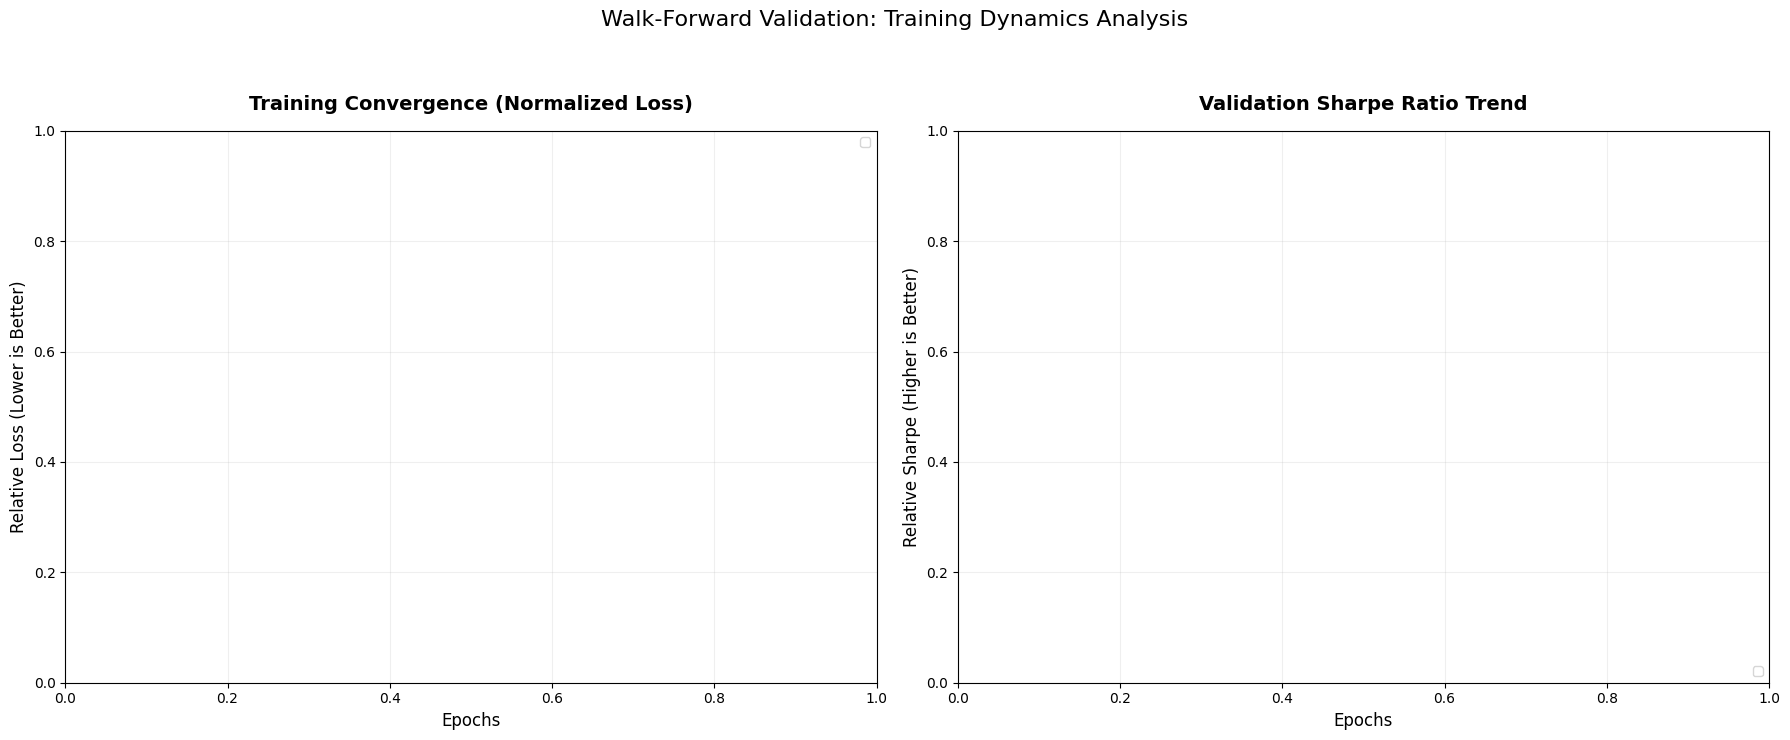

In [53]:
import matplotlib.pyplot as plt
import numpy as np

# Apply professional styling suitable for quantitative reports
plt.style.use('seaborn-v0_8-muted') 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Generate a distinct color palette for the validation folds
colors = plt.cm.viridis(np.linspace(0, 0.8, len(splits)))

for i, split in enumerate(splits):
    fold_num = split.get('fold', i + 1)
    
    if 'history_loss' not in split or len(split['history_loss']) == 0:
        continue
        
    loss = np.array(split['history_loss'])
    sharpe = np.array(split['history_sharpe'])
    epochs = np.arange(1, len(loss) + 1)
    
    # 1. Moving Average Smoothing 
    # Extracts the underlying trend from batch-level stochastic noise
    def smooth(y, box_pts=3):
        box = np.ones(box_pts) / box_pts
        return np.convolve(y, box, mode='same')

    # 2. Dynamic Min-Max Normalization
    # Scales metrics to [0, 1] to compare disparate fold magnitudes on a single axis
    loss_norm = (loss - np.min(loss)) / (np.max(loss) - np.min(loss) + 1e-9)
    sharpe_norm = (sharpe - np.min(sharpe)) / (np.max(sharpe) - np.min(sharpe) + 1e-9)
    
    color = colors[i]
    
    # Plot Loss: Thin line for raw data, thick line for smoothed trend
    ax1.plot(epochs, loss_norm, color=color, alpha=0.2, linewidth=1)
    ax1.plot(epochs, smooth(loss_norm), label=f"Fold {fold_num} (Min: {np.min(loss):.4f})", 
             color=color, linewidth=2.5)
    
    # Plot Sharpe: Thin line for raw data, thick line for smoothed trend
    ax2.plot(epochs, sharpe_norm, color=color, alpha=0.2, linewidth=1)
    ax2.plot(epochs, smooth(sharpe_norm), label=f"Fold {fold_num} (Max: {np.max(sharpe):.4f})", 
             color=color, linewidth=2.5)
    
    # Highlight the epoch with the best validation Sharpe Ratio (Early Stopping point)
    best_epoch_idx = np.argmax(sharpe)
    ax2.scatter(best_epoch_idx + 1, sharpe_norm[best_epoch_idx], 
                color=color, marker='*', s=150, zorder=5, edgecolors='black')

# Formatting Loss Subplot
ax1.set_title('Training Convergence (Normalized Loss)', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Relative Loss (Lower is Better)', fontsize=12)
ax1.grid(True, alpha=0.2)
ax1.legend(loc='upper right', fontsize=9, frameon=True)

# Formatting Sharpe Subplot
ax2.set_title('Validation Sharpe Ratio Trend', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Relative Sharpe (Higher is Better)', fontsize=12)
ax2.grid(True, alpha=0.2)
ax2.legend(loc='lower right', fontsize=9, frameon=True)

plt.suptitle("Walk-Forward Validation: Training Dynamics Analysis", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

Nuove epoche ottimali calcolate: 42


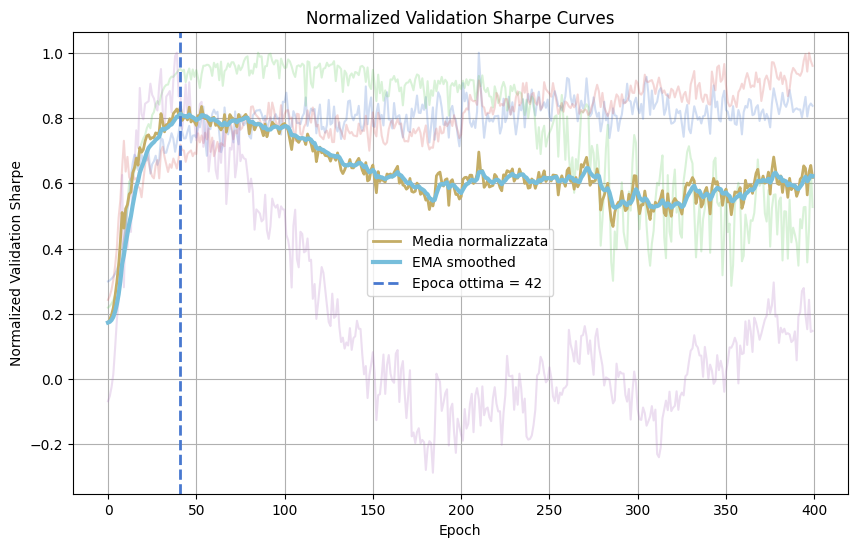

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Estrazione curve
all_val_curves = [np.array(split['history_sharpe']) for split in splits]

# 2. Normalizzazione (max = 1 per ogni curva)
normalized_curves = []
for curve in all_val_curves:
    max_val = np.max(curve)
    if max_val != 0:
        normalized_curve = curve / max_val
    else:
        normalized_curve = curve
    normalized_curves.append(normalized_curve)

normalized_curves = np.array(normalized_curves)

# 3. Curva media normalizzata
global_curve = np.mean(normalized_curves, axis=0)

# 4. Smoothing EMA
smoothing_span = 7
smoothed_curve = pd.Series(global_curve).ewm(
    span=smoothing_span,
    adjust=False
).mean().values

# 5. Epoca ottima
ottimo_strutturale = int(np.argmax(smoothed_curve) + 1)
EPOCHS = ottimo_strutturale

print(f"Nuove epoche ottimali calcolate: {EPOCHS}")

# -----------------------
# PLOT
# -----------------------

plt.figure(figsize=(10,6))

# singole curve normalizzate
for curve in normalized_curves:
    plt.plot(curve, alpha=0.25)

# media
plt.plot(global_curve, linewidth=2, label="Media normalizzata")

# curva smussata
plt.plot(smoothed_curve, linewidth=3, label="EMA smoothed")

# epoca ottima
plt.axvline(
    x=ottimo_strutturale-1,
    linestyle="--",
    linewidth=2,
    label=f"Epoca ottima = {ottimo_strutturale}"
)

plt.xlabel("Epoch")
plt.ylabel("Normalized Validation Sharpe")
plt.title("Normalized Validation Sharpe Curves")
plt.legend()
plt.grid(True)

plt.show()

# Final Model Evaluation on Hold-Out Test Set

In [57]:
#Sharpe bad  190 1234
#Sharpe good  170 1234 
#Linear bad   348  4321 
#Linear good  51  4321

EPOCHS = 350
LEARNING_RATE = 2e-4
BATCH_SIZE = 128
COST_RATE = 0.001
tf.keras.backend.clear_session()

seed_value = 4321
random.seed(seed_value)
np.random.seed(seed_value)
tf.keras.utils.set_random_seed(seed_value)

train_ds = create_dataset(final_split['X_train_tensor'], final_split['y_train_tensor'], is_training=True, seed=seed_value)
test_ds = create_dataset(final_split['X_test_tensor'], final_split['y_test_tensor'], is_training=False)

input_shape = list(final_split['X_train_tensor'].shape[1:])
n_assets = final_split['y_train_tensor'].shape[1] - 1

# Initialize final architecture
final_model = build_robust_lstm_model(input_shape, n_assets)

# Re-initialize optimizer for the new model graph
optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE,
    beta_1=0.9, beta_2=0.999, epsilon=1e-7, clipnorm=1.0
)
optimizer.build(final_model.trainable_variables)

history_test_sharpe = []

print(f"\n{'EPOCH':<5} | {'TR LOSS':<10} | {'TEST SHARPE':<12} | {'TEST RET %':<10} | {'TIME'}")
print("-" * 75)

for epoch in range(EPOCHS):
    start_time = time.time()
    epoch_loss_avg = tf.keras.metrics.Mean()

    # A. Training Iteration (Utilizing previously defined ASAM step)
    for x_batch, y_batch in train_ds:
        total_loss = train_step_asam(final_model, x_batch, y_batch, optimizer, loss_fn, rho=0.1) 
        epoch_loss_avg.update_state(total_loss)

    # B. Out-of-Sample Inference
    test_preds, test_targets = [], []
    for x_test, y_test in test_ds:
        # Direct inference call; no need for a separate tf.function wrapper
        test_preds.append(final_model(x_test, training=False).numpy())
        test_targets.append(y_test.numpy())

    test_weights_full = np.vstack(test_preds)
    test_targets_full = np.vstack(test_targets)

    # C. Performance Evaluation
    metrics = get_sharpe_metrics(test_weights_full, test_targets_full, cost_rate=COST_RATE, n_assets=n_assets)

    current_loss = epoch_loss_avg.result().numpy()
    current_sharpe = metrics['sharpe_annual']
    current_ret_pct = metrics['mean_return_annual'] * 100

    history_test_sharpe.append(current_sharpe)
    elapsed = time.time() - start_time

    print(f"{epoch+1:<5} | {current_loss:.4f}     | {current_sharpe:.4f}       | {current_ret_pct:.2f}%       | {elapsed:.1f}s")

print("-" * 75)
print(f"FINAL SHARPE RATIO (Test Set): {history_test_sharpe[-1]:.4f}")

# Persist optimized weights for future backtesting/deployment
final_model.save_weights("final_model_lstm_portfolio.weights.h5")


EPOCH | TR LOSS    | TEST SHARPE  | TEST RET % | TIME
---------------------------------------------------------------------------
1     | 1.0994     | -0.1269       | -2.23%       | 2.8s
2     | 0.9932     | -0.1027       | -1.71%       | 1.0s
3     | 0.8785     | -0.0604       | -0.94%       | 1.0s
4     | 0.6945     | 0.0111       | 0.15%       | 1.1s
5     | 0.3857     | 0.1977       | 1.81%       | 1.1s
6     | 0.1048     | 0.3458       | 2.80%       | 1.1s
7     | 0.0426     | 0.3643       | 2.90%       | 1.1s
8     | 0.0355     | 0.3274       | 2.49%       | 1.1s
9     | 0.0260     | 0.3243       | 2.41%       | 1.1s
10    | 0.0183     | 0.3206       | 2.34%       | 1.1s
11    | 0.0123     | 0.4099       | 2.99%       | 1.1s
12    | 0.0110     | 0.4038       | 2.93%       | 1.1s
13    | 0.0060     | 0.3728       | 2.67%       | 1.1s
14    | 0.0069     | 0.3331       | 2.37%       | 1.2s
15    | 0.0080     | 0.3854       | 2.75%       | 1.2s
16    | 0.0051     | 0.3671       | 2.

KeyboardInterrupt: 

## Permutation Feature Importance Analysis 

PERMUTATION IMPORTANCE — Full OOS (TensorFlow)
Features in input: 9
Baseline Sharpe: 3.0831

AGG                  | drop Sharpe: +0.0430 ± 0.0403
DBC                  | drop Sharpe: +0.1173 ± 0.0629
VTI                  | drop Sharpe: +0.1975 ± 0.0532
VIX                  | drop Sharpe: +0.7104 ± 0.1855
AGG_Ret              | drop Sharpe: +0.0600 ± 0.1441
DBC_Ret              | drop Sharpe: +0.1287 ± 0.0173
VTI_Ret              | drop Sharpe: +0.4334 ± 0.1973
VIX_Ret              | drop Sharpe: +1.3601 ± 0.4350
RiskFreeRate         | drop Sharpe: +0.0973 ± 0.0760


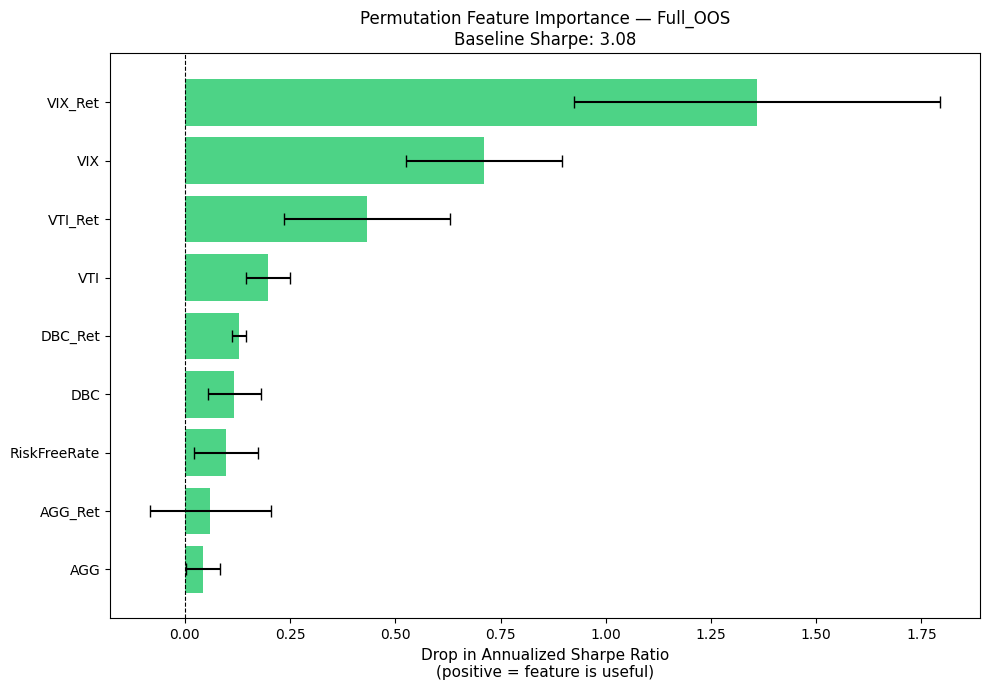

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# ============================================================================
# 2. PERMUTATION IMPORTANCE FUNCTION (TENSORFLOW)
# ============================================================================

def permutation_importance_sharpe(model, X_test, y_test, n_assets, feature_names,
                                   cost_rate=0.001, n_repeats=5, seed=1234):
    """
    Permutation Importance basata sul drop di Sharpe Ratio annualizzato.
    """
    n_features = X_test.shape[2]
    
    if n_features != len(feature_names):
        raise ValueError(f"Mismatch: il tensore ha {n_features} features, ma hai fornito {len(feature_names)} nomi.")
    
    # --- Baseline Sharpe (nessuna permutazione) ---
    baseline_preds = model(tf.constant(X_test, dtype=tf.float32), training=False).numpy()
    baseline_metrics = get_sharpe_metrics(baseline_preds, y_test, 
                                           cost_rate=cost_rate, 
                                           n_assets=n_assets)
    baseline_sharpe = baseline_metrics['sharpe_annual']
    print(f"Baseline Sharpe: {baseline_sharpe:.4f}\n")
    
    results = {}
    rng = np.random.default_rng(seed)
    
    for feat_idx in range(n_features):
        feat_name = feature_names[feat_idx]
        drops = []
        
        for _ in range(n_repeats):
            X_permuted = X_test.copy()
            
            # Shuffling lungo l'asse dei samples
            perm_idx = rng.permutation(X_permuted.shape[0])
            X_permuted[:, :, feat_idx] = X_permuted[perm_idx, :, feat_idx]
            
            # Inferenza TensorFlow con feature rotta
            perm_preds = model(tf.constant(X_permuted, dtype=tf.float32), training=False).numpy()
            
            perm_metrics = get_sharpe_metrics(perm_preds, y_test,
                                               cost_rate=cost_rate,
                                               n_assets=n_assets)
            
            drops.append(baseline_sharpe - perm_metrics['sharpe_annual'])
        
        results[feat_name] = {
            'importance_mean': np.mean(drops),
            'importance_std':  np.std(drops)
        }
        print(f"{feat_name:<20} | drop Sharpe: {np.mean(drops):+.4f} ± {np.std(drops):.4f}")
    
    return baseline_sharpe, results

# ============================================================================
# 3. PLOTTING FUNCTION
# ============================================================================

def plot_permutation_importance(results, baseline_sharpe, regime_label="Full OOS"):
    names  = list(results.keys())
    means  = [results[n]['importance_mean'] for n in names]
    stds   = [results[n]['importance_std']  for n in names]
    
    # Ordinamento decrescente
    order  = np.argsort(means)[::-1]
    names  = [names[i]  for i in order]
    means  = [means[i]  for i in order]
    stds   = [stds[i]   for i in order]
    
    colors = ['#2ecc71' if m > 0 else '#e74c3c' for m in means]
    
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(names, means, xerr=stds, color=colors, 
                   align='center', alpha=0.85, 
                   error_kw=dict(ecolor='black', capsize=4))
    
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Drop in Annualized Sharpe Ratio\n(positive = feature is useful)', fontsize=11)
    ax.set_title(f'Permutation Feature Importance — {regime_label}\nBaseline Sharpe: {baseline_sharpe:.2f}', fontsize=12)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(f'permutation_importance_{regime_label}.png', dpi=150)
    plt.show()

# ============================================================================
# 4. EXECUTION BLOCK
# ============================================================================

# Estrazione sicura dei tensori dal dizionario finale
X_test_np = final_split['X_test_tensor'].numpy() \
            if hasattr(final_split['X_test_tensor'], 'numpy') \
            else np.array(final_split['X_test_tensor'])

y_test_np = final_split['y_test_tensor'].numpy() \
            if hasattr(final_split['y_test_tensor'], 'numpy') \
            else np.array(final_split['y_test_tensor'])

# Configurazione dinamica
COST_RATE = 0.001
seed_value = 1234
dynamic_feature_names = X_cols
n_assets = len([c for c in y_cols if '_Ret' in c])

print("=" * 60)
print("PERMUTATION IMPORTANCE — Full OOS (TensorFlow)")
print(f"Features in input: {len(dynamic_feature_names)}")
print("=" * 60)

baseline_sharpe, imp_results = permutation_importance_sharpe(
    model         = final_model,
    X_test        = X_test_np,
    y_test        = y_test_np,
    n_assets      = n_assets,
    feature_names = dynamic_feature_names,
    cost_rate     = COST_RATE,
    n_repeats     = 5,
    seed          = seed_value
)

plot_permutation_importance(imp_results, baseline_sharpe, "Full_OOS")

## Out-of-Sample Inference and Allocation Plotting

Executing Test Set Inference...


E0000 00:00:1774003848.955180 4526909 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



FINAL MODEL RESULTS (Test Set)
Cost Rate: 10 bps | Risk-Free: Dynamic
         Metric  Value
    Ann. Return 43.80%
Ann. Volatility 14.39%
   Sharpe Ratio 3.0441
   Max Drawdown  6.47%
   Avg Turnover 0.1289
--------------------------------------------------

--- LaTeX Table Code ---
\textbf{Ann. Return} & \textbf{Ann. Vol.} & \textbf{Sharpe} & \textbf{Max DD} \\
\hline
43.80\% & 14.39\% & 3.0441 & 6.47\% \\


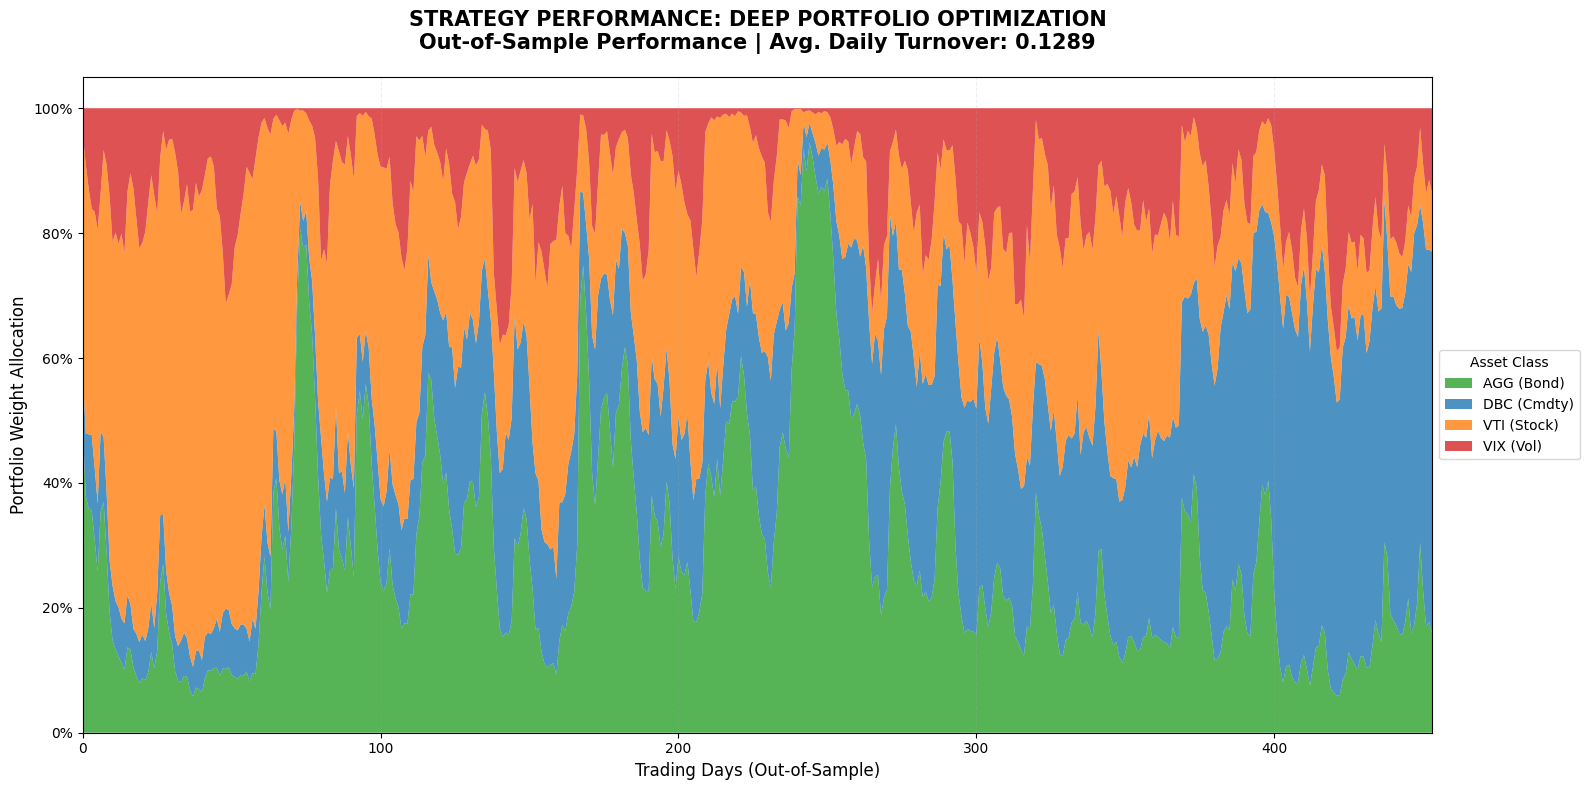

In [14]:
import matplotlib.ticker as mtick

X_test = final_split['X_test_tensor']
y_test = final_split['y_test_tensor']

print("Executing Test Set Inference...")
weights_3d = final_model.predict(X_test, verbose=0)

# Surgical extraction: Portfolio allocation at the final step of the window
weights_final = weights_3d[:, -1, :]
n_assets = weights_final.shape[1]

# --- 1. METRICS EVALUATION & EXTERNAL CALCULATIONS ---
COSTS = 0.001  # 10 basis points (0.1%)

# Call the core function
metrics = get_sharpe_metrics(weights_3d, y_test, COSTS, n_assets)

# External calculation for Maximum Drawdown requires the net returns array.
# We replicate the drift-adjusted net returns logic from the function.
asset_returns = y_test[:, :n_assets]
rf_rate = y_test[:, n_assets]

portfolio_gross_ext = np.sum(weights_final * asset_returns, axis=1)
w_drifted_ext = weights_final * (1 + asset_returns) / (1 + portfolio_gross_ext[:, np.newaxis])
turnover_ext = np.sum(np.abs(weights_final[1:] - w_drifted_ext[:-1]), axis=1)
turnover_full_ext = np.concatenate(([0], turnover_ext))

net_excess_ret_ext = portfolio_gross_ext - (turnover_full_ext * COSTS) - rf_rate

# Maximum Drawdown (Cumulative sum approximation)
cumulative_returns = np.cumsum(net_excess_ret_ext)
peak = np.maximum.accumulate(cumulative_returns)
drawdown = peak - cumulative_returns
max_dd = np.max(drawdown)

# --- 2. FORMATTED OUTPUT & LATEX EXPORT ---
metrics_df = pd.DataFrame({
    "Metric": ["Ann. Return", "Ann. Volatility", "Sharpe Ratio", "Max Drawdown", "Avg Turnover"],
    "Value": [
        f"{metrics['mean_return_annual']*100:.2f}%", 
        f"{metrics['volatility_annual']*100:.2f}%", 
        f"{metrics['sharpe_annual']:.4f}", 
        f"{max_dd*100:.2f}%",
        f"{metrics['avg_daily_turnover']:.4f}"
    ]
})

print("\n" + "="*50)
print("FINAL MODEL RESULTS (Test Set)")
print(f"Cost Rate: {COSTS*10000:.0f} bps | Risk-Free: Dynamic")
print("="*50)
print(metrics_df.to_string(index=False))
print("-" * 50)

# Generation of LaTeX row for direct paper injection
latex_row = (f"{metrics['mean_return_annual']*100:.2f}\\% & "
             f"{metrics['volatility_annual']*100:.2f}\\% & "
             f"{metrics['sharpe_annual']:.4f} & "
             f"{max_dd*100:.2f}\\%")

print("\n--- LaTeX Table Code ---")
print(r"\textbf{Ann. Return} & \textbf{Ann. Vol.} & \textbf{Sharpe} & \textbf{Max DD} \\")
print(r"\hline")
print(f"{latex_row} \\\\")
print("="*50)

# --- 3. PORTFOLIO ALLOCATION VISUALIZATION ---
def plot_allocation_robust(weights, title_set, avg_turnover):
    """
    Renders a stacked area chart of asset weights over the out-of-sample period.
    """
    time_axis = np.arange(len(weights))
    weights_T = weights.T
    
    asset_labels = ['AGG (Bond)', 'DBC (Cmdty)', 'VTI (Stock)', 'VIX (Vol)']
    if weights.shape[1] != len(asset_labels):
        asset_labels = [f'Asset {i+1}' for i in range(weights.shape[1])]
        
    colors = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728']

    plt.figure(figsize=(16, 8))
    plt.stackplot(time_axis, weights_T, labels=asset_labels, colors=colors, alpha=0.8)

    title_text = f"{title_set}\nOut-of-Sample Performance | Avg. Daily Turnover: {avg_turnover:.4f}"
    
    plt.title(title_text, fontsize=15, fontweight='bold', pad=20)
    plt.xlabel("Trading Days (Out-of-Sample)", fontsize=12)
    plt.ylabel("Portfolio Weight Allocation", fontsize=12)
    
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Asset Class")
    plt.grid(True, axis='x', alpha=0.2, linestyle='--')
    plt.margins(x=0)
    plt.tight_layout()
    plt.show()

# Execute plot using previously calculated data
plot_allocation_robust(weights_final, "STRATEGY PERFORMANCE: DEEP PORTFOLIO OPTIMIZATION", metrics['avg_daily_turnover'])

## Dynamic Portfolio-Level Volatility Scaling

In [114]:
import numpy as np
import pandas as pd

# ============================================================================
# 1. CORE FUNCTION: PORTFOLIO VOLATILITY (EX-ANTE EWMA)
# ============================================================================

def calculate_portfolio_volatility(weights, returns, window=50):
    """
    Calculates the Ex-Ante volatility of the aggregated portfolio.
    Ensures that volatility at time T depends strictly on information up to T-1
    to prevent forward-looking bias.
    """
    T = len(returns)
    
    # Calculate shadow returns of the portfolio to estimate historical strategy volatility
    portfolio_raw_rets = np.sum(weights * returns, axis=1)
    portfolio_vol = np.zeros(T)
    
    alpha = 2 / (window + 1)
    
    # Warm-up: Simple standard deviation for the initial window stability
    initial_std = np.std(portfolio_raw_rets[:window])
    portfolio_vol[:window] = initial_std
    
    current_var = initial_std**2

    # Recursive EWMA update
    for t in range(window, T):
        r_prev = portfolio_raw_rets[t-1]
        current_var = alpha * (r_prev**2) + (1 - alpha) * current_var
        portfolio_vol[t] = np.sqrt(current_var)

    return portfolio_vol * np.sqrt(252)

# ============================================================================
# 2. SCALING FUNCTION: DYNAMIC LEVERAGE APPLICATION
# ============================================================================

def apply_portfolio_scaling(weights, returns, rf_rate, vol_target, cost_rate=0.001):
    """
    Applies macro-level Volatility Scaling to the portfolio.
    Formula: Weights_Scaled = Weights_Raw * (Vol_Target / Vol_Portfolio_Est)
    """
    # 1. Ex-Ante Portfolio Volatility Estimation
    port_vol_est = calculate_portfolio_volatility(weights, returns, window=50)

    # 2. Dynamic Leverage Factor Calculation
    leverage_factors = vol_target / (port_vol_est + 1e-9)

    # 3. Apply Leverage to Weights
    scaled_weights = weights * leverage_factors[:, np.newaxis]

    # 4. Gross Returns & Transaction Costs (incorporating leverage shifts)
    gross_returns = np.sum(scaled_weights * returns, axis=1)
    
    scaled_weights_prev = np.vstack([scaled_weights[0], scaled_weights[:-1]])
    turnover = np.sum(np.abs(scaled_weights - scaled_weights_prev), axis=1)
    transaction_costs = turnover * cost_rate

    # 5. Net and Excess Returns
    net_returns = gross_returns - transaction_costs
    excess_returns = net_returns - rf_rate

    # 6. KPI Calculation
    FREQ = 252
    ann_return = np.mean(excess_returns) * FREQ
    ann_vol = np.std(net_returns) * np.sqrt(FREQ)
    sharpe = ann_return / ann_vol if ann_vol != 0 else 0

    downside = net_returns[net_returns < 0]
    dd_std = np.std(downside) * np.sqrt(FREQ) if len(downside) > 0 else 1e-9
    sortino = ann_return / dd_std

    cumulative = np.cumsum(net_returns)
    peak = np.maximum.accumulate(cumulative)
    mdd = np.max(peak - cumulative)

    return {
        'ann_return': ann_return,
        'ann_vol': ann_vol,
        'sharpe': sharpe,
        'sortino': sortino,
        'max_dd': mdd,
        'avg_leverage': np.mean(leverage_factors),
        'avg_turnover': np.mean(turnover)
    }

# ============================================================================
# 3. EXECUTION AND COMPARATIVE ANALYSIS
# ============================================================================

VOLATILITY_TARGETS = [0.1, 0.15, 0.20]

print("\n" + "="*75)
print("PORTFOLIO-LEVEL VOLATILITY SCALING - COMPARATIVE ANALYSIS")
print("="*75)

results_list = []

for vt in VOLATILITY_TARGETS:
    res = apply_portfolio_scaling(
        weights=weights_final,  
        returns=asset_returns,      
        rf_rate=rf_rate,            
        vol_target=vt,
        cost_rate=COSTS
    )

    results_list.append({
        "Target Vol": f"{vt*100:.0f}%",
        "Ann. Return": f"{res['ann_return']*100:.2f}%",
        "Ann. Vol": f"{res['ann_vol']*100:.2f}%",
        "Sharpe": f"{res['sharpe']:.4f}",
        "Sortino": f"{res['sortino']:.4f}",
        "Max DD": f"{res['max_dd']*100:.2f}%",
        "Avg Lev": f"{res['avg_leverage']:.2f}x",
        "Turnover": f"{res['avg_turnover']:.4f}"
    })

df_res = pd.DataFrame(results_list)
print(df_res.to_string(index=False))
print("="*75)


PORTFOLIO-LEVEL VOLATILITY SCALING - COMPARATIVE ANALYSIS
Target Vol Ann. Return Ann. Vol Sharpe Sortino Max DD Avg Lev Turnover
       10%      11.76%   10.56% 1.1137  2.4038  7.68%   1.11x   0.1245
       15%      19.92%   15.84% 1.2576  2.7143 11.52%   1.67x   0.1867
       20%      28.08%   21.12% 1.3295  2.8696 15.36%   2.22x   0.2489


# Static Benchmark Evaluation (Out-of-Sample)

In [58]:
import numpy as np
import pandas as pd

# ============================================================================
# 1. METRICS CALCULATION (EXCESS RETURNS)
# ============================================================================

def compute_portfolio_metrics_excess(portfolio_returns, risk_free_rate, freq=252):
    """
    Calculates key performance indicators based on Net Excess Returns.
    """
    # Daily Excess Returns calculation
    excess_returns = portfolio_returns - risk_free_rate
    
    # 1. Annualized Return (Excess)
    ann_excess_return = np.mean(excess_returns) * freq
    
    # 2. Annualized Volatility
    ann_std = np.std(portfolio_returns) * np.sqrt(freq)
    
    # 3. Sharpe Ratio
    sharpe = ann_excess_return / ann_std if ann_std != 0 else 0
    
    # 4. Downside Deviation and Sortino Ratio
    # Penalizes only negative excess returns
    downside_diff = np.where(excess_returns < 0, excess_returns, 0)
    downside_std = np.std(downside_diff) * np.sqrt(freq)
    sortino = ann_excess_return / downside_std if downside_std != 0 else 0
    
    # 5. Maximum Drawdown (MDD) based on total returns
    cumulative = np.cumsum(portfolio_returns)
    peak = np.maximum.accumulate(cumulative)
    drawdown = peak - cumulative
    mdd = np.max(drawdown)
    
    return {
        "Ann. Excess Return": ann_excess_return,
        "Ann. Volatility": ann_std,
        "Sharpe Ratio": sharpe,
        "Sortino Ratio": sortino,
        "Max Drawdown": mdd
    }

# ============================================================================
# 2. BENCHMARK COMPARISON EXECUTION
# ============================================================================

# Extract synchronized test targets from the final split
y_test_raw = final_split['y_test_tensor'] 

# Isolate asset returns (first 4 columns) and Risk-Free rate (last column)
asset_returns_test = y_test_raw[:, :4]
rf_test = y_test_raw[:, 4]

# Define static baseline portfolios (Fixed allocation weights)
baseline_allocations = {
    "Naive":     np.array([0.05, 0.20, 0.65, 0.10])
}

test_comparison = {}

for name, weights in baseline_allocations.items():
    # Calculate daily gross returns for the static portfolio via dot product
    p_ret = np.dot(asset_returns_test, weights)
    
    # Compute metrics using Risk-Free adjusted returns
    test_comparison[name] = compute_portfolio_metrics_excess(p_ret, rf_test)

# ============================================================================
# 3. FORMATTED OUTPUT
# ============================================================================
df_test_metrics = pd.DataFrame(test_comparison).T

print("\n" + "="*80)
print("STATIC BENCHMARK PERFORMANCE (Final Test Set - Excess Returns)")
print("="*80)
print(df_test_metrics.round(4).to_string())
print("="*80)


STATIC BENCHMARK PERFORMANCE (Final Test Set - Excess Returns)
       Ann. Excess Return  Ann. Volatility  Sharpe Ratio  Sortino Ratio  Max Drawdown
Naive              0.2173           0.0951        2.2836         5.1781        0.0433


## Benchmarking with Portfolio-Level Volatility Scaling

In [44]:
import numpy as np
import pandas as pd

# ============================================================================
# 1. SCALING FUNCTION FOR FIXED WEIGHT BENCHMARKS
# ============================================================================

def apply_vol_scaling_benchmarks(fixed_weights, returns, rf_rate, vol_target, cost_rate=0.001, window=50):
    """
    Applies volatility scaling to static benchmark portfolios (e.g., 1/N, 60/40).
    Incorporates drift-adjusted transaction costs for daily rebalancing.
    Excludes the initial warm-up period from metric calculations to ensure true OOS evaluation.
    """
    T, n_assets = returns.shape
    
    # Broadcast static weights across the entire time horizon
    weights_matrix = np.tile(fixed_weights, (T, 1))
    
    # 1. Estimate Ex-Ante Volatility (Function calculate_portfolio_volatility must be in scope)
    port_vol_annual = calculate_portfolio_volatility(weights_matrix, returns, window=window)
    
    # 2. Derive Dynamic Leverage Factors (Capped to prevent extreme leverage)
    scaling_factors = vol_target / (port_vol_annual + 1e-9)
    MAX_LEVERAGE = 3.0
    scaling_factors = np.clip(scaling_factors, 0, MAX_LEVERAGE)
    
    # 3. Apply Volatility Scaling to Static Weights
    scaled_weights = weights_matrix * scaling_factors[:, np.newaxis]
    
    # 4. Gross Returns Calculation
    gross_ret = np.sum(scaled_weights * returns, axis=1)
    
    # 5. Drift-Adjusted Turnover & Transaction Costs
    # Even if target weights are fixed, daily asset returns cause the portfolio to drift.
    w_drifted = scaled_weights * (1 + returns) / (1 + gross_ret[:, np.newaxis])
    
    # Turnover from yesterday's drifted weights to today's rebalanced and scaled weights
    turnover = np.sum(np.abs(scaled_weights[1:] - w_drifted[:-1]), axis=1)
    turnover_full = np.concatenate(([0], turnover))
    transaction_costs = turnover_full * cost_rate
    
    # 6. Net and Excess Returns
    net_ret = gross_ret - transaction_costs
    
    # 7. Strictly Out-Of-Sample Metrics (Filtering out the static warm-up phase)
    oos_net_ret = net_ret[window:]
    oos_rf_rate = rf_rate[window:]
    oos_turnover = turnover_full[window:]
    
    # Assuming compute_portfolio_metrics_excess is defined in your environment
    metrics = compute_portfolio_metrics_excess(oos_net_ret, oos_rf_rate)
    metrics['avg_turnover'] = np.mean(oos_turnover)
    
    return metrics

# ============================================================================
# 2. COMPARATIVE EXECUTION (Target Vol: 9%)
# ============================================================================

VOL_TARGET = 0.085 # 9% Annualized Risk Target
WINDOW_ESTIMATION = 50
COSTS = 0.001

# Assuming y_test_tensor and baseline_allocations dict are already in scope
y_test_raw = final_split['y_test_tensor'] 
asset_returns_test = y_test_raw[:, :4]
rf_test = y_test_raw[:, 4]

baseline_results = {}

print(f"\n{'STRATEGY':<20} | {'ANN RET':<10} | {'VOL':<8} | {'SHARPE':<8} | {'MAX DD':<8} | {'TURNOVER':<8}")
print("-" * 75)

for name, weights in baseline_allocations.items():
    res = apply_vol_scaling_benchmarks(
        fixed_weights=weights,
        returns=asset_returns_test,
        rf_rate=rf_test,
        vol_target=VOL_TARGET,
        cost_rate=COSTS,
        window=WINDOW_ESTIMATION
    )
    
    baseline_results[name] = res
    
    # Safe key extraction assuming compute_portfolio_metrics_excess standard output
    ann_ret = res.get('Ann. Excess Return', res.get('ann_return', 0))
    ann_vol = res.get('Ann. Volatility', res.get('ann_vol', 0))
    sharpe = res.get('Sharpe Ratio', res.get('sharpe', 0))
    max_dd = res.get('Max Drawdown', res.get('max_dd', 0))
    avg_turnover = res.get('avg_turnover', 0)
    
    print(f"{name:<20} | {ann_ret*100:>7.2f}% | {ann_vol*100:>6.2f}% | {sharpe:>7.4f} | {max_dd*100:>6.2f}% | {avg_turnover:>6.4f}")

print("-" * 75)


STRATEGY             | ANN RET    | VOL      | SHARPE   | MAX DD   | TURNOVER
---------------------------------------------------------------------------


NameError: name 'calculate_portfolio_volatility' is not defined

# Maximum Diversification (MD) Rolling Optimization

In [59]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sklearn.covariance import ledoit_wolf

# ============================================================================
# 1. CORE OPTIMIZER: CONVEX QUADRATIC FORMULATION
# ============================================================================

def solve_md_weights(cov_matrix):
    """
    Maximizes the Diversification Ratio using the robust convex formulation.
    Minimizes auxiliary portfolio variance subject to a unity weighted-volatility constraint.
    """
    n_assets = cov_matrix.shape[0]
    sigma = np.sqrt(np.diag(cov_matrix))
    
    # Minimize auxiliary portfolio variance
    def objective(x):
        return np.dot(x.T, np.dot(cov_matrix, x))
    
    # Unity weighted-volatility constraint
    constraints = ({'type': 'eq', 'fun': lambda x: np.dot(x, sigma) - 1.0})
    bounds = tuple((0.0, None) for _ in range(n_assets))
    
    # Valid initial guess satisfying the constraint
    init_guess = np.ones(n_assets) / np.sum(sigma)
    
    res = minimize(objective, init_guess, method='SLSQP', 
                   bounds=bounds, constraints=constraints, tol=1e-9)
    
    if res.success:
        # Rescale auxiliary variables to sum to 1
        return res.x / np.sum(res.x)
    return np.ones(n_assets) / n_assets

# ============================================================================
# 2. ROLLING BACKTEST EXECUTION (FULL OOS PRESERVATION)
# ============================================================================

WINDOW = 63  # 1-Quarter operational lookback
COSTS = 0.001

# Assuming 'final_split' dictionary is loaded in the environment
y_train_rescaled = final_split['y_train_tensor']
y_test_rescaled = final_split['y_test_tensor']

returns_train = y_train_rescaled[:, :4]
returns_test = y_test_rescaled[:, :4]
rf_test = y_test_rescaled[:, 4]

# Pre-pend the last WINDOW days of training data to evaluate the entire test set
extended_returns = np.vstack([returns_train[-WINDOW:], returns_test])
n_test_obs = returns_test.shape[0]

md_weights_list = []

for t in range(WINDOW, WINDOW + n_test_obs):
    lookback = extended_returns[t-WINDOW:t, :]
    
    # Ledoit-Wolf Shrinkage guarantees positive definiteness and matrix stability
    cov_matrix, _ = ledoit_wolf(lookback)
    md_weights_list.append(solve_md_weights(cov_matrix))

md_weights = np.array(md_weights_list)

# ============================================================================
# 3. PERFORMANCE EVALUATION (VECTORIZED DRIFT ADJUSTMENT)
# ============================================================================

# Gross Returns calculation
gross_portfolio_ret = np.sum(md_weights * returns_test, axis=1)

# Vectorized weight drift calculation
# w_drifted[t] represents the effective market weights at the close of day t
w_drifted = md_weights * (1 + returns_test) / (1 + gross_portfolio_ret[:, np.newaxis])

# Turnover is the L1 norm between today's target weights and yesterday's drifted weights
turnover = np.sum(np.abs(md_weights[1:] - w_drifted[:-1]), axis=1)

# Neutralize initial turnover assuming the portfolio was pre-allocated
turnover_full = np.concatenate(([0], turnover))
transaction_costs = turnover_full * COSTS

net_portfolio_ret = gross_portfolio_ret - transaction_costs
excess_returns = net_portfolio_ret - rf_test

# ============================================================================
# 4. KPI SUMMARY
# ============================================================================

# Assuming compute_portfolio_metrics_excess is defined in your environment
metrics_md = compute_portfolio_metrics_excess(net_portfolio_ret, rf_test)
metrics_md['Avg Turnover'] = np.mean(turnover_full)

print("\n" + "="*50)
print("MAXIMUM DIVERSIFICATION (MD) BENCHMARK RESULTS")
print(f"Estimation Window: {WINDOW} days | Cost Rate: {COSTS*10000:.0f} bps")
print("="*50)

# Format and print the final metrics dynamically
for k, v in metrics_md.items():
    if 'Turnover' in k or 'Sharpe' in k or 'Sortino' in k:
        print(f"{k:20}: {v:.4f}")
    else:
        print(f"{k:20}: {v*100:.2f}%")
print("="*50)


MAXIMUM DIVERSIFICATION (MD) BENCHMARK RESULTS
Estimation Window: 63 days | Cost Rate: 10 bps
Ann. Excess Return  : 13.55%
Ann. Volatility     : 11.22%
Sharpe Ratio        : 1.2078
Sortino Ratio       : 2.2190
Max Drawdown        : 8.31%
Avg Turnover        : 0.0194


## Maximum Diversification Allocation Visualization

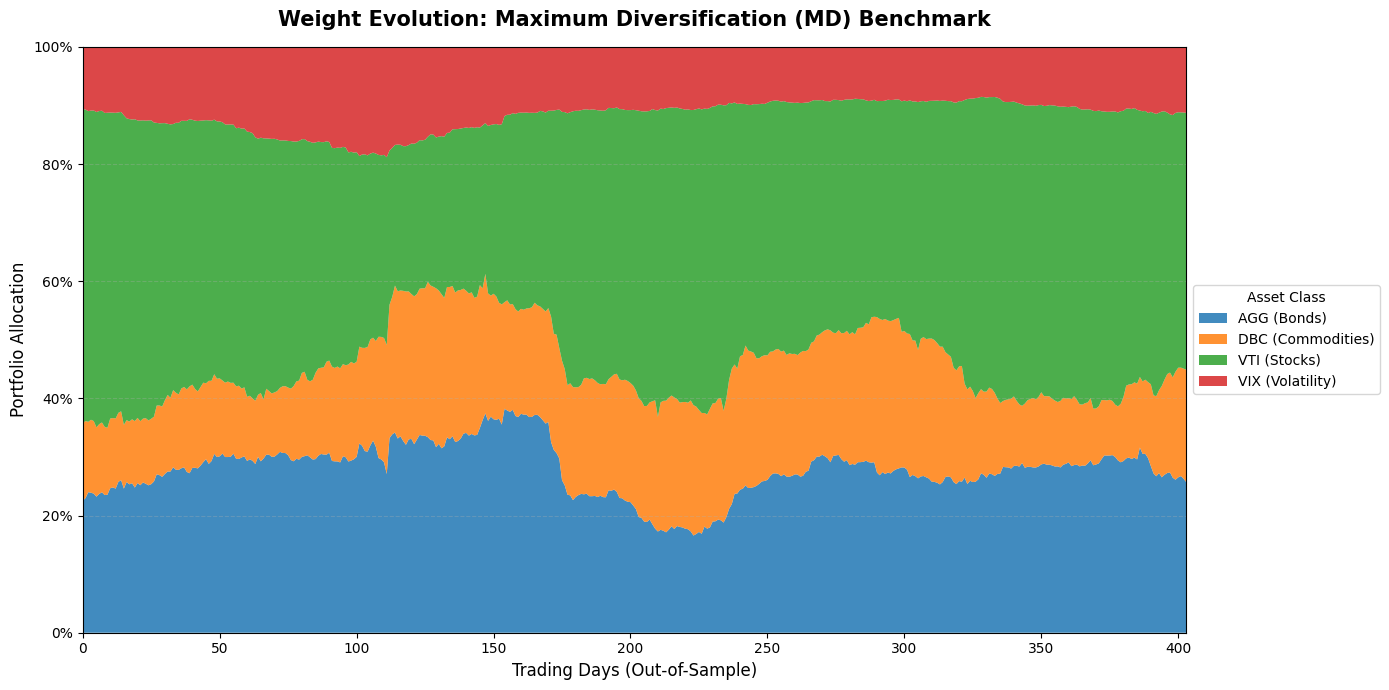

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ============================================================================
# MAXIMUM DIVERSIFICATION (MD) DYNAMIC ALLOCATION PLOT
# ============================================================================

# Use a generic numerical time axis to match the Deep Portfolio plot
time_axis = np.arange(len(md_weights))

asset_labels = ['AGG (Bonds)', 'DBC (Commodities)', 'VTI (Stocks)', 'VIX (Volatility)']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, ax = plt.subplots(figsize=(14, 7))

# Render the stacked area chart
ax.stackplot(time_axis, md_weights.T, 
             labels=asset_labels, 
             colors=colors, 
             alpha=0.85)

# Aesthetic formatting and labeling
ax.set_title('Weight Evolution: Maximum Diversification (MD) Benchmark', fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('Portfolio Allocation', fontsize=12)
ax.set_xlabel('Trading Days (Out-of-Sample)', fontsize=12)

# Legend positioning
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10, title="Asset Class")

# Axis optimization
ax.set_ylim(0, 1)
ax.set_xlim(0, len(time_axis) - 1 if len(time_axis) > 0 else 1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## Maximum Diversification with Volatility Scaling

In [47]:
import numpy as np
import pandas as pd

# ============================================================================
# 1. CORE FUNCTION: PORTFOLIO VOLATILITY (EX-ANTE EWMA)
# ============================================================================

def calculate_portfolio_volatility(weights, returns, window=50):
    """
    Calculates the Ex-Ante volatility of the aggregated portfolio returns.
    Ensures that volatility at time t depends strictly on information up to t-1
    to prevent forward-looking bias.
    """
    T = len(returns)
    
    # Calculate shadow returns of the strategy to estimate historical volatility
    portfolio_raw_rets = np.sum(weights * returns, axis=1)
    portfolio_vol = np.zeros(T)
    
    alpha = 2 / (window + 1)
    
    # Warm-up phase: Static standard deviation for initial stability
    initial_std = np.std(portfolio_raw_rets[:window])
    portfolio_vol[:window] = initial_std
    
    current_var = initial_std**2

    # Recursive EWMA update
    for t in range(window, T):
        r_prev = portfolio_raw_rets[t-1]
        current_var = alpha * (r_prev**2) + (1 - alpha) * current_var
        portfolio_vol[t] = np.sqrt(current_var)

    return portfolio_vol * np.sqrt(252)

# ============================================================================
# 2. SCALING FUNCTION: DYNAMIC LEVERAGE APPLICATION (DRIFT ADJUSTED)
# ============================================================================

def apply_portfolio_scaling(weights, returns, rf_rate, vol_target, cost_rate=0.001, window=50, max_leverage=3.0):
    """
    Applies macro-level Volatility Scaling to the portfolio.
    Calculates drift-adjusted transaction costs and outputs metrics evaluated
    strictly on the out-of-sample period (post warm-up).
    """
    # 1. Ex-Ante Portfolio Volatility Estimation
    port_vol_est = calculate_portfolio_volatility(weights, returns, window=window)

    # 2. Dynamic Leverage Factor Calculation (Capped to prevent extreme margin usage)
    leverage_factors = vol_target / (port_vol_est + 1e-9)
    leverage_factors = np.clip(leverage_factors, 0, max_leverage)

    # 3. Apply Leverage to Weights
    scaled_weights = weights * leverage_factors[:, np.newaxis]

    # 4. Gross Returns Calculation
    gross_returns = np.sum(scaled_weights * returns, axis=1)
    
    # 5. Drift-Adjusted Turnover & Transaction Costs
    w_drifted = scaled_weights * (1 + returns) / (1 + gross_returns[:, np.newaxis])
    
    # Turnover is calculated between yesterday's drifted weights and today's new targets
    turnover = np.sum(np.abs(scaled_weights[1:] - w_drifted[:-1]), axis=1)
    
    # Neutralize initial turnover assuming pre-funded portfolio
    turnover_full = np.concatenate(([0], turnover))
    transaction_costs = turnover_full * cost_rate

    # 6. Net and Excess Returns
    net_returns = gross_returns - transaction_costs
    excess_returns = net_returns - rf_rate

    # 7. KPI Calculation (Strictly Out-of-Sample evaluation)
    oos_excess_returns = excess_returns[window:]
    oos_net_returns = net_returns[window:]
    oos_turnover = turnover_full[window:]
    oos_leverage = leverage_factors[window:]

    FREQ = 252
    ann_return = np.mean(oos_excess_returns) * FREQ
    ann_vol = np.std(oos_net_returns) * np.sqrt(FREQ)
    sharpe = ann_return / ann_vol if ann_vol != 0 else 0

    downside = oos_net_returns[oos_net_returns < 0]
    dd_std = np.std(downside) * np.sqrt(FREQ) if len(downside) > 0 else 1e-9
    sortino = ann_return / dd_std

    cumulative = np.cumsum(oos_net_returns)
    peak = np.maximum.accumulate(cumulative)
    mdd = np.max(peak - cumulative)

    return {
        'ann_return': ann_return,
        'ann_vol': ann_vol,
        'sharpe': sharpe,
        'sortino': sortino,
        'max_dd': mdd,
        'avg_leverage': np.mean(oos_leverage),
        'avg_turnover': np.mean(oos_turnover)
    }

# ============================================================================
# 3. EXECUTION AND COMPARATIVE ANALYSIS
# ============================================================================

VOLATILITY_TARGETS = [0.095, 0.15, 0.20]
WINDOW_ESTIMATION = 50
COSTS = 0.001

# Recupero corretto dei dati dal test set
# Assumiamo che md_weights sia stato calcolato sui returns_test
y_test_raw = final_split['y_test_tensor']
asset_returns_test = y_test_raw[:, :4] # Le prime 4 colonne sono i rendimenti
rf_test = y_test_raw[:, 4]            # La quinta colonna è il Risk-Free

print("\n" + "="*80)
print("PORTFOLIO-LEVEL VOLATILITY SCALING - COMPARATIVE ANALYSIS")
print("="*80)

results_list = []

for vt in VOLATILITY_TARGETS:
    # Passiamo asset_returns_test e rf_test invece di nomi generici
    res = apply_portfolio_scaling(
        weights=md_weights,  
        returns=asset_returns_test,      
        rf_rate=rf_test,            
        vol_target=vt,
        cost_rate=COSTS,
        window=WINDOW_ESTIMATION
    )

    results_list.append({
        "Target Vol": f"{vt*100:.0f}%",
        "Ann. Return": f"{res['ann_return']*100:.2f}%",
        "Ann. Vol": f"{res['ann_vol']*100:.2f}%",
        "Sharpe": f"{res['sharpe']:.4f}",
        "Sortino": f"{res['sortino']:.4f}",
        "Max DD": f"{res['max_dd']*100:.2f}%",
        "Avg Lev": f"{res['avg_leverage']:.2f}x",
        "Turnover": f"{res['avg_turnover']:.4f}"
    })

df_res = pd.DataFrame(results_list)
print(df_res.to_string(index=False))
print("="*80)


PORTFOLIO-LEVEL VOLATILITY SCALING - COMPARATIVE ANALYSIS
Target Vol Ann. Return Ann. Vol Sharpe Sortino Max DD Avg Lev Turnover
       10%       5.84%    9.67% 0.6035  1.2615  3.83%   1.21x   0.0352
       15%      12.02%   15.27% 0.7875  1.6461  6.05%   1.92x   0.0554
       20%      16.74%   19.75% 0.8478  1.7569  8.07%   2.48x   0.0663


# Markowitz Mean-Variance (MV) Optimization & Plotting

Executing Markowitz GMV Optimization (Window: 63 days)...

MARKOWITZ MIN-VARIANCE (GMV) BENCHMARK RESULTS
Estimation Window: 63 days | Cost Rate: 10 bps
Ann. Excess Return  : 9.84%
Ann. Volatility     : 6.89%
Sharpe Ratio        : 1.4288
Sortino Ratio       : 2.5391
Max Drawdown        : 4.17%
Avg Turnover        : 0.0119


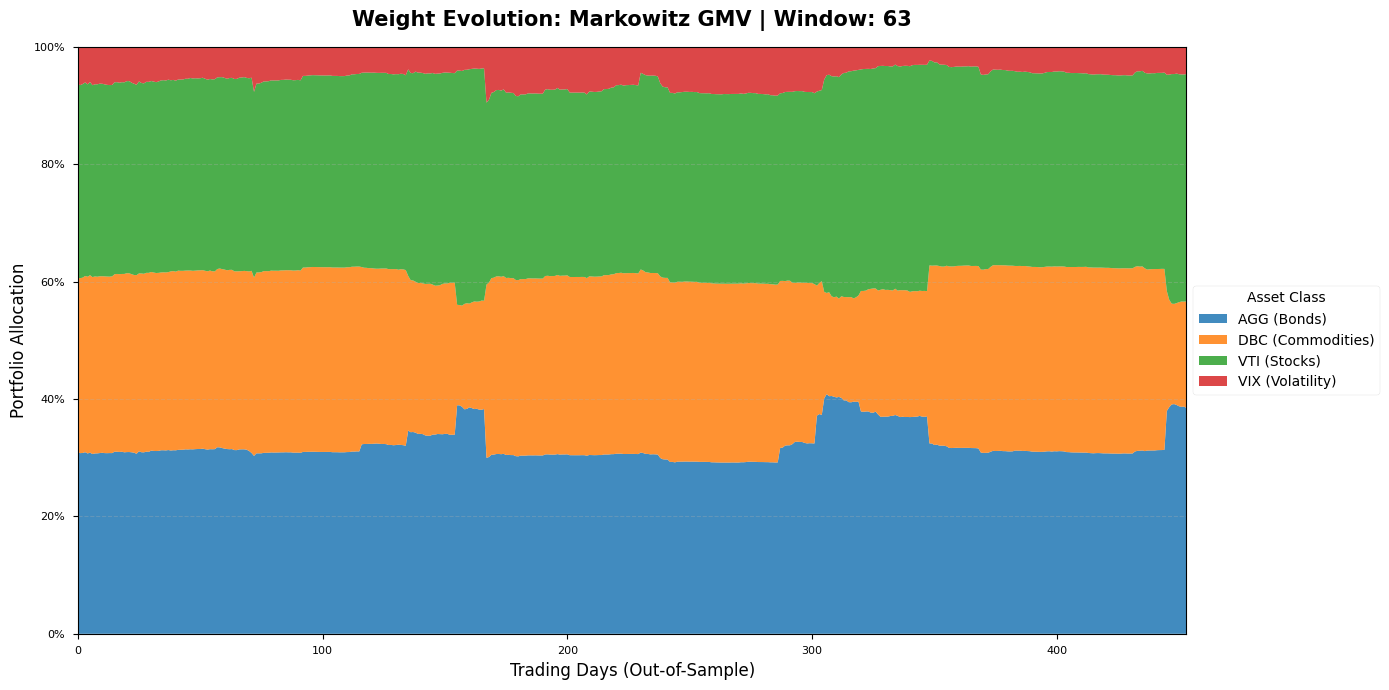

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.optimize import minimize
from sklearn.covariance import ledoit_wolf

# ============================================================================
# 1. CORE OPTIMIZER: GLOBAL MINIMUM VARIANCE (MARKOWITZ)
# ============================================================================

WINDOW = 63  # 1-Quarter operational lookback
COSTS = 0.001

def solve_gmv_weights(cov_matrix):
    """
    Solves the Markowitz Global Minimum Variance (GMV) portfolio.
    Ignores noisy expected returns and focuses entirely on robust covariance 
    to minimize overall portfolio risk.
    """
    n_assets = cov_matrix.shape[0]
    
    def objective(w):
        # Minimize portfolio variance directly
        return np.dot(w.T, np.dot(cov_matrix, w))

    # Constraints: Fully invested (sum=1)
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0})
    
    # Bounds: Long-only (0 to 1)
    bounds = tuple((0.0, 1.0) for _ in range(n_assets))
    
    # Equal risk contribution initial guess
    init_guess = np.ones(n_assets) / n_assets

    res = minimize(objective, init_guess, method='SLSQP', 
                   bounds=bounds, constraints=constraints, tol=1e-9)
                   
    return res.x if res.success else init_guess

# ============================================================================
# 2. ROLLING BACKTEST EXECUTION (FULL OOS PRESERVATION)
# ============================================================================

# Assuming 'final_split' dictionary is loaded in the environment
y_train_rescaled = final_split['y_train_tensor']
y_test_rescaled = final_split['y_test_tensor']

returns_train = y_train_rescaled[:, :4]
returns_test = y_test_rescaled[:, :4]
rf_test = y_test_rescaled[:, 4]

# Pre-pend the last WINDOW days of training data to evaluate the entire test set
extended_returns = np.vstack([returns_train[-WINDOW:], returns_test])
n_test_obs = returns_test.shape[0]

mv_weights_list = []

print(f"Executing Markowitz GMV Optimization (Window: {WINDOW} days)...")

for t in range(WINDOW, WINDOW + n_test_obs):
    lookback_returns = extended_returns[t-WINDOW:t, :]
    
    # Robust Covariance Estimation (Ledoit-Wolf Shrinkage)
    sigma_matrix, _ = ledoit_wolf(lookback_returns)
    
    mv_weights_list.append(solve_gmv_weights(sigma_matrix))

# Array perfectly aligned with the returns_test timeframe
mv_weights = np.array(mv_weights_list)

# ============================================================================
# 3. PERFORMANCE EVALUATION (VECTORIZED DRIFT ADJUSTMENT)
# ============================================================================

# Gross Returns calculation
gross_portfolio_ret = np.sum(mv_weights * returns_test, axis=1)

# Vectorized weight drift calculation
# Weights drift end-of-day proportionally to individual asset returns
w_drifted = mv_weights * (1 + returns_test) / (1 + gross_portfolio_ret[:, np.newaxis])

# Turnover is the absolute difference between yesterday's drifted weights and today's targets
turnover = np.sum(np.abs(mv_weights[1:] - w_drifted[:-1]), axis=1)

# Neutralize initial turnover
turnover_full = np.concatenate(([0], turnover))
transaction_costs = turnover_full * COSTS

net_portfolio_ret = gross_portfolio_ret - transaction_costs
excess_returns = net_portfolio_ret - rf_test

# ============================================================================
# 4. KPI SUMMARY
# ============================================================================

# Assuming compute_portfolio_metrics_excess is defined in your environment
metrics_mv = compute_portfolio_metrics_excess(net_portfolio_ret, rf_test)
metrics_mv['Avg Turnover'] = np.mean(turnover_full)

print("\n" + "="*50)
print("MARKOWITZ MIN-VARIANCE (GMV) BENCHMARK RESULTS")
print(f"Estimation Window: {WINDOW} days | Cost Rate: {COSTS*10000:.0f} bps")
print("="*50)

for k, v in metrics_mv.items():
    if 'Turnover' in k or 'Sharpe' in k or 'Sortino' in k:
        print(f"{k:<20}: {v:.4f}")
    else:
        print(f"{k:<20}: {v*100:.2f}%")
print("="*50)

# ============================================================================
# 5. DYNAMIC ALLOCATION PLOT
# ============================================================================

time_axis = np.arange(len(mv_weights))
asset_labels = ['AGG (Bonds)', 'DBC (Commodities)', 'VTI (Stocks)', 'VIX (Volatility)']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, ax = plt.subplots(figsize=(14, 7))

ax.stackplot(time_axis, mv_weights.T, labels=asset_labels, colors=colors, alpha=0.85)

ax.set_title(f'Weight Evolution: Markowitz GMV | Window: {WINDOW}', 
             fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('Portfolio Allocation', fontsize=12)
ax.set_xlabel('Trading Days (Out-of-Sample)', fontsize=12)

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10, title="Asset Class")

ax.set_ylim(0, 1)
ax.set_xlim(0, len(time_axis) - 1 if len(time_axis) > 0 else 1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## Markowitz Mean-Variance with Asset-Level Volatility Scaling

In [49]:
import numpy as np
import pandas as pd

# ============================================================================
# 1. CORE FUNCTION: PORTFOLIO VOLATILITY (EX-ANTE EWMA)
# ============================================================================

def calculate_portfolio_volatility(weights, returns, window=50):
    """
    Calculates the Ex-Ante volatility of the aggregated portfolio returns.
    Ensures that volatility at time t depends strictly on information up to t-1
    to prevent forward-looking bias.
    """
    T = len(returns)
    
    # Calculate shadow returns of the strategy to estimate historical volatility
    portfolio_raw_rets = np.sum(weights * returns, axis=1)
    portfolio_vol = np.zeros(T)
    
    alpha = 2 / (window + 1)
    
    # Warm-up phase: Static standard deviation for initial stability
    initial_std = np.std(portfolio_raw_rets[:window])
    portfolio_vol[:window] = initial_std
    
    current_var = initial_std**2

    # Recursive EWMA update
    for t in range(window, T):
        r_prev = portfolio_raw_rets[t-1]
        current_var = alpha * (r_prev**2) + (1 - alpha) * current_var
        portfolio_vol[t] = np.sqrt(current_var)

    return portfolio_vol * np.sqrt(252)

# ============================================================================
# 2. SCALING FUNCTION: DYNAMIC LEVERAGE APPLICATION (DRIFT ADJUSTED)
# ============================================================================

def apply_portfolio_scaling(weights, returns, rf_rate, vol_target, cost_rate=0.001, window=50, max_leverage=3.0):
    """
    Applies macro-level Volatility Scaling to the portfolio.
    Calculates drift-adjusted transaction costs and outputs metrics evaluated
    strictly on the out-of-sample period (post warm-up).
    """
    # 1. Ex-Ante Portfolio Volatility Estimation
    port_vol_est = calculate_portfolio_volatility(weights, returns, window=window)

    # 2. Dynamic Leverage Factor Calculation (Capped to prevent extreme margin usage)
    leverage_factors = vol_target / (port_vol_est + 1e-9)
    leverage_factors = np.clip(leverage_factors, 0, max_leverage)

    # 3. Apply Leverage to Weights
    scaled_weights = weights * leverage_factors[:, np.newaxis]

    # 4. Gross Returns Calculation
    gross_returns = np.sum(scaled_weights * returns, axis=1)
    
    # 5. Drift-Adjusted Turnover & Transaction Costs
    w_drifted = scaled_weights * (1 + returns) / (1 + gross_returns[:, np.newaxis])
    
    # Turnover is calculated between yesterday's drifted weights and today's new targets
    turnover = np.sum(np.abs(scaled_weights[1:] - w_drifted[:-1]), axis=1)
    
    # Neutralize initial turnover assuming pre-funded portfolio
    turnover_full = np.concatenate(([0], turnover))
    transaction_costs = turnover_full * cost_rate

    # 6. Net and Excess Returns
    net_returns = gross_returns - transaction_costs
    excess_returns = net_returns - rf_rate

    # 7. KPI Calculation (Strictly Out-of-Sample evaluation)
    oos_excess_returns = excess_returns[window:]
    oos_net_returns = net_returns[window:]
    oos_turnover = turnover_full[window:]
    oos_leverage = leverage_factors[window:]

    FREQ = 252
    ann_return = np.mean(oos_excess_returns) * FREQ
    ann_vol = np.std(oos_net_returns) * np.sqrt(FREQ)
    sharpe = ann_return / ann_vol if ann_vol != 0 else 0

    downside = oos_net_returns[oos_net_returns < 0]
    dd_std = np.std(downside) * np.sqrt(FREQ) if len(downside) > 0 else 1e-9
    sortino = ann_return / dd_std

    cumulative = np.cumsum(oos_net_returns)
    peak = np.maximum.accumulate(cumulative)
    mdd = np.max(peak - cumulative)

    return {
        'ann_return': ann_return,
        'ann_vol': ann_vol,
        'sharpe': sharpe,
        'sortino': sortino,
        'max_dd': mdd,
        'avg_leverage': np.mean(oos_leverage),
        'avg_turnover': np.mean(oos_turnover)
    }

# ============================================================================
# 3. EXECUTION AND COMPARATIVE ANALYSIS
# ============================================================================

VOLATILITY_TARGETS = [0.1, 0.15, 0.20]
WINDOW_ESTIMATION = 50
COSTS = 0.001

# Correct data recovery from the test tensor
y_test_raw = final_split['y_test_tensor']
asset_returns = y_test_raw[:, :4]  # First 4 columns: Asset Returns
rf_rate = y_test_raw[:, 4]         # 5th column: Risk-Free Rate

print("\n" + "="*80)
print("PORTFOLIO-LEVEL VOLATILITY SCALING - COMPARATIVE ANALYSIS")
print("="*80)

results_list = []

for vt in VOLATILITY_TARGETS:
    res = apply_portfolio_scaling(
        weights=mv_weights,  
        returns=asset_returns,      
        rf_rate=rf_rate,            
        vol_target=vt,
        cost_rate=COSTS,
        window=WINDOW_ESTIMATION
    )

    results_list.append({
        "Target Vol": f"{vt*100:.0f}%",
        "Ann. Return": f"{res['ann_return']*100:.2f}%",
        "Ann. Vol": f"{res['ann_vol']*100:.2f}%",
        "Sharpe": f"{res['sharpe']:.4f}",
        "Sortino": f"{res['sortino']:.4f}",
        "Max DD": f"{res['max_dd']*100:.2f}%",
        "Avg Lev": f"{res['avg_leverage']:.2f}x",
        "Turnover": f"{res['avg_turnover']:.4f}"
    })

df_res = pd.DataFrame(results_list)
print(df_res.to_string(index=False))
print("="*80)


PORTFOLIO-LEVEL VOLATILITY SCALING - COMPARATIVE ANALYSIS
Target Vol Ann. Return Ann. Vol Sharpe Sortino Max DD Avg Lev Turnover
       10%       2.94%   10.20% 0.2885  0.5657  5.90%   1.49x   0.0524
       15%       7.72%   15.10% 0.5111  1.0238  7.24%   2.20x   0.0731
       20%      10.25%   18.79% 0.5456  1.0811  9.48%   2.73x   0.0811


# TSmixer

In [18]:
import os
import time
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
#good 20 4321 
#bad 150 1234
# --- 1. RIPRODUCIBILITÀ ASSOLUTA ---
SEED = 1234
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. CONVERSIONE DATALOADER ---
BATCH_SIZE = 128
LEARNING_RATE = 2e-4
MAX_EPOCHS = 2
FINAL_EPOCHS = 150
COST_RATE = 0.001
N_ASSETS = final_split['y_train_tensor'].shape[1] - 1
WINDOW = final_split['X_train_tensor'].shape[1]
INPUT_CHANNELS = final_split['X_train_tensor'].shape[2]

def convert_to_pytorch_loader(X_array, y_array, batch_size, is_training, seed=1234):
    X_tensor = torch.tensor(X_array, dtype=torch.float32)
    y_tensor = torch.tensor(y_array, dtype=torch.float32)
    dataset = TensorDataset(X_tensor, y_tensor)
    
    if is_training:
        generator = torch.Generator()
        generator.manual_seed(seed)
        return DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True, generator=generator)
    else:
        return DataLoader(dataset, batch_size=batch_size, shuffle=False)

for split in splits:
    split['train_loader'] = convert_to_pytorch_loader(split['X_train_tensor'], split['y_train_tensor'], BATCH_SIZE, True, SEED)
    split['val_loader'] = convert_to_pytorch_loader(split['X_val_tensor'], split['y_val_tensor'], BATCH_SIZE, False)

strain_loader = convert_to_pytorch_loader(final_split['X_train_tensor'], final_split['y_train_tensor'], BATCH_SIZE, True, SEED)
test_loader = convert_to_pytorch_loader(final_split['X_test_tensor'], final_split['y_test_tensor'], BATCH_SIZE, False)

# --- 3. ARCHITETTURA MODELLO E LOSS ---
class TSMixerBlock(nn.Module):
    def __init__(self, hidden_dim, seq_len, dropout=0.3):
        super().__init__()
        self.norm_time = nn.BatchNorm1d(hidden_dim)
        self.time_mlp = nn.Sequential(nn.Linear(seq_len, seq_len), nn.GELU(), nn.Dropout(dropout), nn.Linear(seq_len, seq_len))
        self.norm_feat = nn.LayerNorm(hidden_dim)
        self.feat_mlp = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden_dim, hidden_dim))

    def forward(self, x):
        res = x
        x = self.time_mlp(self.norm_time(x.transpose(1, 2))).transpose(1, 2)
        x = x + res
        res = x
        x = self.feat_mlp(self.norm_feat(x))
        return x + res

class TSMixerPortfolio(nn.Module):
    def __init__(self, input_channels, n_assets, seq_len, hidden_dim=64, n_blocks=2, dropout=0.3):
        super().__init__()
        self.input_norm = nn.BatchNorm1d(input_channels)
        self.input_proj = nn.Linear(input_channels, hidden_dim)
        self.blocks = nn.ModuleList([TSMixerBlock(hidden_dim, seq_len, dropout) for _ in range(n_blocks)])
        self.head_mlp = nn.Sequential(nn.Linear(hidden_dim * 2, hidden_dim), nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden_dim, n_assets))
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.input_proj(self.input_norm(x.transpose(1, 2)).transpose(1, 2))
        for block in self.blocks:
            x = block(x)
        combined = torch.cat([x[:, -1, :], x.mean(dim=1)], dim=1)
        return self.softmax(self.head_mlp(combined))

class StabilizedSharpeLoss(nn.Module):
    def __init__(self, cost_coeff=0.001, concentration_coeff=0, annualization_factor=1.0):
        super(StabilizedSharpeLoss, self).__init__()
        self.cost_coeff = cost_coeff
        self.concentration_coeff = concentration_coeff
        self.factor = annualization_factor

    def forward(self, w_t, w_t_prev, y_true):
        if y_true.dim() == 3:
            y_true = y_true.squeeze(1) if y_true.shape[1] == 1 else y_true[:, -1, :]

        asset_returns = y_true[:, :-1]
        rf_rate = y_true[:, -1]

        gross_ret = torch.sum(w_t * asset_returns, dim=1)

        turnover = torch.sqrt(torch.pow(w_t - w_t_prev, 2) + 1e-6).sum(dim=1)
        costs = turnover * self.cost_coeff

        net_excess_ret = gross_ret - costs - rf_rate

        mean_net_ret = torch.mean(net_excess_ret)
        std_net_ret = torch.std(net_excess_ret) + 1e-8
        sharpe_ratio = (mean_net_ret / std_net_ret) * self.factor

        concentration_penalty = torch.mean(torch.sum(w_t ** 2, dim=1))

        return -sharpe_ratio + (self.concentration_coeff * concentration_penalty)

def calculate_real_net_metric(all_weights, all_targets, cost_rate):
    targets = all_targets.squeeze(1) if all_targets.dim() == 3 else all_targets
    asset_returns = targets[:, :-1]
    rf_rate = targets[:, -1]
    
    # 1. Calcolo rendimenti lordi
    gross_ret = torch.sum(all_weights * asset_returns, dim=1)
    
    # 2. Calcolo dei pesi derivati (Drift)
    # w_drifted[t] rappresenta i pesi effettivi a fine giornata t
    w_drifted = all_weights * (1 + asset_returns) / (1 + gross_ret.unsqueeze(1))
    
    # 3. Calcolo del Turnover con drift
    turnover = torch.zeros(all_weights.shape[0], device=all_weights.device)
    # La distanza è calcolata tra l'allocazione target di oggi e l'allocazione driftata di ieri
    turnover[1:] = torch.sum(torch.abs(all_weights[1:] - w_drifted[:-1]), dim=1)
    
    costs = turnover * cost_rate
    net_excess_ret = gross_ret - costs - rf_rate
    
    mean_net = torch.mean(net_excess_ret)
    std_total = torch.std(gross_ret) + 1e-8
    
    return (mean_net / std_total) * np.sqrt(252), mean_net * 252

# --- 4. WALK-FORWARD VALIDATION ---
print(f"{'FOLD':<4} | {'EPOCH':<5} | {'TR LOSS':<10} | {'VAL SHARPE':<10} | {'VAL RET %':<10} | {'TIME':<6}")
print("-" * 80)

for split in splits:
    fold_idx = split['fold']
    torch.manual_seed(SEED)
    model = TSMixerPortfolio(INPUT_CHANNELS, N_ASSETS, WINDOW).to(device)
    criterion = StabilizedSharpeLoss(cost_coeff=COST_RATE).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    
    best_val_sharpe = -float('inf')
    best_weights = None
    
    for epoch in range(MAX_EPOCHS):
        start_time = time.time()
        model.train()
        train_loss_accum = 0
        
        for x, y_combined in split['train_loader']:
            x, y_combined = x.to(device), y_combined.to(device)
            optimizer.zero_grad()
            w_t = model(x)
            w_t_prev = model(torch.cat([x[:, 0:1, :], x[:, :-1, :]], dim=1))
            loss = criterion(w_t, w_t_prev, y_combined)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss_accum += loss.item()

        avg_train_loss = train_loss_accum / len(split['train_loader'])
        
        model.eval()
        val_weights_list, val_targets_list = [], []
        with torch.no_grad():
            for x, y_combined in split['val_loader']:
                x, y_combined = x.to(device), y_combined.to(device)
                val_weights_list.append(model(x))
                val_targets_list.append(y_combined)

        full_val_weights = torch.cat(val_weights_list, dim=0)
        full_val_targets = torch.cat(val_targets_list, dim=0)

        current_sharpe, current_ret = calculate_real_net_metric(full_val_weights, full_val_targets, COST_RATE)
        
        marker = ""
        if current_sharpe > best_val_sharpe:
            best_val_sharpe = current_sharpe
            best_weights = copy.deepcopy(model.state_dict())
            marker = "*"
            
        elapsed = time.time() - start_time
        if (epoch + 1) % 10 == 0 or marker == "*":
            print(f"{fold_idx:<4} | {epoch+1:<5} | {avg_train_loss:.4f}     | {current_sharpe:.4f}     | {current_ret*100:.2f}%       | {elapsed:.1f}s {marker}")

    if best_weights is not None:
        model.load_state_dict(best_weights)
        print(f"--> Fold {fold_idx} completato. Best Sharpe: {best_val_sharpe:.4f}")
    print("-" * 80)

# --- 5. FINAL HOLD-OUT TEST ---
torch.manual_seed(SEED)
final_model = TSMixerPortfolio(INPUT_CHANNELS, N_ASSETS, WINDOW).to(device)
final_criterion = StabilizedSharpeLoss(cost_coeff=COST_RATE).to(device)
final_optimizer = optim.AdamW(final_model.parameters(), lr=LEARNING_RATE)

print(f"\n{'EPOCH':<5} | {'TR LOSS':<10} | {'TEST SHARPE':<12} | {'TEST RET %':<10} | {'TIME'}")
print("-" * 75)

for epoch in range(FINAL_EPOCHS):
    start_time = time.time()
    final_model.train()
    train_loss_accum = 0
    for x, y_combined in strain_loader:
        x, y_combined = x.to(device), y_combined.to(device)
        final_optimizer.zero_grad()
        w_t = final_model(x)
        w_t_prev = final_model(torch.cat([x[:, 0:1, :], x[:, :-1, :]], dim=1))
        loss = final_criterion(w_t, w_t_prev, y_combined)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(final_model.parameters(), max_norm=1.0)
        final_optimizer.step()
        train_loss_accum += loss.item()
        
    avg_train_loss = train_loss_accum / len(strain_loader)

    final_model.eval()
    test_weights_list, test_targets_list = [], []
    with torch.no_grad():
        for x_test, y_test in test_loader:
            x_test, y_test = x_test.to(device), y_test.to(device)
            test_weights_list.append(final_model(x_test))
            test_targets_list.append(y_test)
            
    test_weights_full = torch.cat(test_weights_list, dim=0)
    test_targets_full = torch.cat(test_targets_list, dim=0)
    
    current_sharpe, current_ret = calculate_real_net_metric(test_weights_full, test_targets_full, COST_RATE)
    elapsed = time.time() - start_time
    
    print(f"{epoch+1:<5} | {avg_train_loss:.4f}     | {current_sharpe:.4f}       | {current_ret*100:.2f}%       | {elapsed:.1f}s")

print("-" * 75)
print(f"FINAL SHARPE RATIO (Test Set): {current_sharpe:.4f}")

FOLD | EPOCH | TR LOSS    | VAL SHARPE | VAL RET %  | TIME  
--------------------------------------------------------------------------------
1    | 1     | 0.0023     | -0.1135     | -3.44%       | 0.8s *
1    | 2     | -0.0046     | -0.0975     | -2.88%       | 0.7s *
--> Fold 1 completato. Best Sharpe: -0.0975
--------------------------------------------------------------------------------
2    | 1     | 0.0052     | 0.2856     | 10.24%       | 0.7s *
2    | 2     | 0.0048     | 0.3434     | 12.14%       | 0.7s *
--> Fold 2 completato. Best Sharpe: 0.3434
--------------------------------------------------------------------------------
3    | 1     | 0.0023     | 0.3382     | 9.72%       | 0.8s *
3    | 2     | -0.0080     | 0.4501     | 12.63%       | 0.8s *
--> Fold 3 completato. Best Sharpe: 0.4501
--------------------------------------------------------------------------------
4    | 1     | 0.0063     | 0.5875     | 20.93%       | 0.9s *
4    | 2     | -0.0078     | 0.6668     |

KeyboardInterrupt: 

## Performance evaluation

In [137]:
# --- 6. DETAILED PERFORMANCE EVALUATION ---
final_model.eval()
with torch.no_grad():
    # Estrazione dati dal test set
    targets = test_targets_full.squeeze(1) if test_targets_full.dim() == 3 else test_targets_full
    asset_returns = targets[:, :-1]
    rf_rate = targets[:, -1]
    w_t = test_weights_full
    
    # 1. Calcolo Gross Returns
    gross_ret = torch.sum(w_t * asset_returns, dim=1)
    
    # 2. Calcolo Drifted Weights e Turnover (Econometric Consistency)
    # w_drifted[t] = pesi a fine giornata dopo il movimento dei prezzi
    w_drifted = w_t * (1 + asset_returns) / (1 + gross_ret.unsqueeze(1))
    
    # Turnover[t] = cambio tra target di oggi e pesi driftati di ieri
    turnover = torch.zeros(w_t.shape[0], device=w_t.device)
    turnover[1:] = torch.sum(torch.abs(w_t[1:] - w_drifted[:-1]), dim=1)
    
    # 3. Net Returns ed Excess Returns
    costs = turnover * COST_RATE
    net_ret = gross_ret - costs
    net_excess_ret = net_ret - rf_rate
    
    # 4. Annualizzazione (T=252)
    ann_ret = torch.mean(net_excess_ret) * 252
    ann_vol = torch.std(net_excess_ret) * np.sqrt(252)
    sharpe = ann_ret / (ann_vol + 1e-8)
    
    # 5. Maximum Drawdown (MDD)
    # Calcolo basato sulla curva dei rendimenti cumulati netti
    cum_net_ret = torch.cumsum(net_ret, dim=0)
    running_max = torch.cummax(cum_net_ret, dim=0).values
    drawdowns = running_max - cum_net_ret
    max_dd = torch.max(drawdowns)
    
    # 6. Metrics Summary
    avg_turnover = torch.mean(turnover)
    
    print("\n" + "="*50)
    print("FINAL TEST SET PERFORMANCE METRICS")
    print("="*50)
    print(f"{'Ann. Excess Return:':<25} {ann_ret.item()*100:>10.2f}%")
    print(f"{'Ann. Volatility:':<25} {ann_vol.item()*100:>10.2f}%")
    print(f"{'Sharpe Ratio:':<25} {sharpe.item():>10.4f}")
    print(f"{'Max Drawdown:':<25} {max_dd.item()*100:>10.2f}%")
    print(f"{'Avg Daily Turnover:':<25} {avg_turnover.item():>10.4f}")
    print("="*50)


FINAL TEST SET PERFORMANCE METRICS
Ann. Excess Return:            16.64%
Ann. Volatility:               18.46%
Sharpe Ratio:                 0.9015
Max Drawdown:                  12.64%
Avg Daily Turnover:           0.3007


## Volatility Scaling

In [ ]:
import numpy as np
import pandas as pd

def calculate_portfolio_volatility(weights, returns, window=50):
    """
    Calculates the Ex-Ante volatility of the aggregated portfolio returns (EWMA).
    """
    T = len(returns)
    portfolio_raw_rets = np.sum(weights * returns, axis=1)
    portfolio_vol = np.zeros(T)
    alpha = 2 / (window + 1)
    
    initial_std = np.std(portfolio_raw_rets[:window])
    portfolio_vol[:window] = initial_std
    current_var = initial_std**2

    for t in range(window, T):
        r_prev = portfolio_raw_rets[t-1]
        current_var = alpha * (r_prev**2) + (1 - alpha) * current_var
        portfolio_vol[t] = np.sqrt(current_var)

    return portfolio_vol * np.sqrt(252)

def apply_portfolio_scaling(weights, returns, rf_rate, vol_target, cost_rate=0.001, window=50):
    """
    Applies macro-level Volatility Scaling with drift-adjusted turnover costs.
    """
    # 1. Ex-Ante Portfolio Volatility Estimation
    port_vol_est = calculate_portfolio_volatility(weights, returns, window=window)

    # 2. Dynamic Leverage Factor Calculation (Capped at 3x for stability)
    leverage_factors = np.clip(vol_target / (port_vol_est + 1e-9), 0, 3.0)

    # 3. Apply Leverage to Weights
    scaled_weights = weights * leverage_factors[:, np.newaxis]

    # 4. Gross Returns & Drift-Adjusted Turnover
    gross_returns = np.sum(scaled_weights * returns, axis=1)
    
    # Market Drift calculation for turnover consistency
    w_drifted = scaled_weights * (1 + returns) / (1 + gross_returns[:, np.newaxis])
    
    turnover = np.zeros(len(scaled_weights))
    turnover[1:] = np.sum(np.abs(scaled_weights[1:] - w_drifted[:-1]), axis=1)
    transaction_costs = turnover * cost_rate

    # 5. Net and Excess Returns
    net_returns = gross_returns - transaction_costs
    excess_returns = net_returns - rf_rate

    # 6. KPI Calculation (Strictly OOS)
    oos_excess = excess_returns[window:]
    oos_net = net_returns[window:]
    oos_turnover = turnover[window:]
    
    FREQ = 252
    ann_return = np.mean(oos_excess) * FREQ
    ann_vol = np.std(oos_net) * np.sqrt(FREQ)
    sharpe = ann_return / ann_vol if ann_vol != 0 else 0

    cumulative = np.cumsum(oos_net)
    peak = np.maximum.accumulate(cumulative)
    mdd = np.max(peak - cumulative)

    return {
        'ann_return': ann_return,
        'ann_vol': ann_vol,
        'sharpe': sharpe,
        'max_dd': mdd,
        'avg_leverage': np.mean(leverage_factors[window:]),
        'avg_turnover': np.mean(oos_turnover)
    }

# Preparation of NumPy arrays from Torch tensors
weights_np = test_weights_full.cpu().numpy()
returns_np = asset_returns_pt.cpu().numpy()
rf_np = rf_rate_pt.cpu().numpy()

VOLATILITY_TARGETS = [0.1, 0.15, 0.20]
results_list = []

print("\n" + "="*75)
print("PORTFOLIO-LEVEL VOLATILITY SCALING - COMPARATIVE ANALYSIS")
print("="*75)

for vt in VOLATILITY_TARGETS:
    res = apply_portfolio_scaling(
        weights=weights_np,  
        returns=returns_np,      
        rf_rate=rf_np,            
        vol_target=vt,
        cost_rate=COST_RATE
    )

    results_list.append({
        "Target Vol": f"{vt*100:.0f}%",
        "Ann. Return": f"{res['ann_return']*100:.2f}%",
        "Ann. Vol": f"{res['ann_vol']*100:.2f}%",
        "Sharpe": f"{res['sharpe']:.4f}",
        "Max DD": f"{res['max_dd']*100:.2f}%",
        "Avg Lev": f"{res['avg_leverage']:.2f}x",
        "Turnover": f"{res['avg_turnover']:.4f}"
    })

df_res = pd.DataFrame(results_list)
print(df_res.to_string(index=False))
print("="*75)


FINAL TEST SET PERFORMANCE METRICS (BASELINE)
Ann. Excess Return:            16.64%
Ann. Volatility:               18.46%
Sharpe Ratio:                 0.9015
Max Drawdown:                  12.64%
Avg Daily Turnover:           0.3007

PORTFOLIO-LEVEL VOLATILITY SCALING - COMPARATIVE ANALYSIS
Target Vol Ann. Return Ann. Vol Sharpe Max DD Avg Lev Turnover
       10%       7.71%   10.83% 0.7119  6.54%   0.63x   0.1889
       15%      13.90%   16.24% 0.8562  9.80%   0.95x   0.2831
       20%      20.10%   21.65% 0.9284 13.07%   1.26x   0.3773


# Confidence test

In [62]:
# ============================================================================
# STATISTICAL SIGNIFICANCE TESTING — Circular Block Bootstrap only
# Runs after: GMV block (mv_weights), MD block (md_weights),
#             Naive block (baseline_allocations), DLS training loop
# ============================================================================

from scipy import stats as sp_stats
from sklearn.covariance import ledoit_wolf
from scipy.optimize import minimize

# Fallback definitions — used only if benchmark blocks were not run
def solve_gmv_weights(cov_matrix):
    n = cov_matrix.shape[0]
    ones = np.ones(n)
    res = minimize(lambda w: w @ cov_matrix @ w,
                   ones / n, method='SLSQP',
                   bounds=[(0, 1)] * n,
                   constraints={'type': 'eq', 'fun': lambda w: w.sum() - 1},
                   tol=1e-9)
    return res.x if res.success else ones / n

def solve_md_weights(cov_matrix):
    n     = cov_matrix.shape[0]
    sigma = np.sqrt(np.diag(cov_matrix))
    res   = minimize(lambda x: x @ cov_matrix @ x,
                     np.ones(n) / sigma.sum(), method='SLSQP',
                     bounds=[(0, None)] * n,
                     constraints={'type': 'eq', 'fun': lambda x: x @ sigma - 1},
                     tol=1e-9)
    return res.x / res.x.sum() if res.success else np.ones(n) / n


# ============================================================================
# A. UNIFIED NET EXCESS RETURN RECONSTRUCTOR
# ============================================================================

def compute_net_excess_returns(weights_2d, asset_returns, rf_rate, cost_rate):
    gross         = np.sum(weights_2d * asset_returns, axis=1)
    w_drifted     = weights_2d * (1 + asset_returns) / (1 + gross[:, np.newaxis])
    turnover      = np.sum(np.abs(weights_2d[1:] - w_drifted[:-1]), axis=1)
    turnover_full = np.concatenate(([0.0], turnover))
    return gross - turnover_full * cost_rate - rf_rate


# ============================================================================
# B. CIRCULAR BLOCK BOOTSTRAP  (robust to non-normality and autocorrelation)
# ============================================================================

def bootstrap_sharpe_diff_ci(r_a, r_b, n_boot=10_000, ci=0.95,
                              ann_factor=252, seed=1234):
    """
    Circular block bootstrap for the difference SR_A - SR_B.
    Block length = floor(sqrt(T)) — Andrews (1991) heuristic.
    Pairs (r_a, r_b) resampled jointly to preserve cross-strategy correlation.

    Returns
    -------
    dict with observed SR difference, percentile CI and empirical p-value
    """
    rng       = np.random.default_rng(seed)
    n         = len(r_a)
    r_ab      = np.column_stack([r_a, r_b])          # (T, 2)
    block_len = max(int(np.floor(np.sqrt(n))), 1)

    def sr_diff(mat):
        a, b = mat[:, 0], mat[:, 1]
        return ((a.mean() / (a.std(ddof=1) + 1e-9)) -
                (b.mean() / (b.std(ddof=1) + 1e-9))) * np.sqrt(ann_factor)

    obs_diff   = sr_diff(r_ab)
    boot_diffs = np.empty(n_boot)

    for i in range(n_boot):
        starts        = rng.integers(0, n, size=int(np.ceil(n / block_len)))
        indices       = np.concatenate(
            [(np.arange(s, s + block_len) % n) for s in starts]
        )[:n]
        boot_diffs[i] = sr_diff(r_ab[indices])

    alpha = 1 - ci
    lo    = float(np.percentile(boot_diffs, 100 * alpha / 2))
    hi    = float(np.percentile(boot_diffs, 100 * (1 - alpha / 2)))

    return {
        'obs_SR_diff':       round(obs_diff, 4),
        f'CI_{int(ci*100)}': (round(lo, 4), round(hi, 4)),
        'contains_zero':     lo <= 0.0 <= hi,
        'p_empirical':       round(float(np.mean(boot_diffs <= 0)), 4),
        'block_len':         block_len,
    }


# ============================================================================
# C. ASSEMBLE NET EXCESS RETURN SERIES
#    Guard clauses recompute any benchmark weights not already in memory
# ============================================================================

_asset_ret = final_split['y_test_tensor'][:, :4]
_rf        = final_split['y_test_tensor'][:, 4]
_T         = len(_rf)

if 'mv_weights' not in dir() and 'mv_weights' not in vars():
    print("mv_weights not found — recomputing GMV rolling backtest...")
    _returns_train = final_split['y_train_tensor'][:, :4]
    _extended      = np.vstack([_returns_train[-WINDOW:], _asset_ret])
    mv_weights     = np.array([
        solve_gmv_weights(ledoit_wolf(_extended[_t - WINDOW:_t, :])[0])
        for _t in range(WINDOW, WINDOW + _T)
    ])
    print(f"  Done. Shape: {mv_weights.shape}")

if 'md_weights' not in dir() and 'md_weights' not in vars():
    print("md_weights not found — recomputing MD rolling backtest...")
    _returns_train = final_split['y_train_tensor'][:, :4]
    _extended      = np.vstack([_returns_train[-WINDOW:], _asset_ret])
    md_weights     = np.array([
        solve_md_weights(ledoit_wolf(_extended[_t - WINDOW:_t, :])[0])
        for _t in range(WINDOW, WINDOW + _T)
    ])
    print(f"  Done. Shape: {md_weights.shape}")

if 'baseline_allocations' not in dir() and 'baseline_allocations' not in vars():
    baseline_allocations = {"Naive": np.array([0.05, 0.20, 0.65, 0.10])}

_dls_w   = test_weights_full[:, -1, :]
_mv_w    = mv_weights[-_T:]
_md_w    = md_weights[-_T:]
_naive_w = np.tile(baseline_allocations["Naive"], (_T, 1))

assert _dls_w.shape == _mv_w.shape == _md_w.shape == _naive_w.shape, (
    f"Shape mismatch: DLS={_dls_w.shape}, GMV={_mv_w.shape}, "
    f"MD={_md_w.shape}, Naive={_naive_w.shape}"
)

r_dls   = compute_net_excess_returns(_dls_w,   _asset_ret, _rf, COSTS)
r_mv    = compute_net_excess_returns(_mv_w,    _asset_ret, _rf, COSTS)
r_md    = compute_net_excess_returns(_md_w,    _asset_ret, _rf, COSTS)
r_naive = compute_net_excess_returns(_naive_w, _asset_ret, _rf, 0.0)

print(f"\nReturn series assembled — length: {_T} obs each")
print(f"  SR check  DLS={r_dls.mean()/r_dls.std()*np.sqrt(252):.3f} | "
      f"GMV={r_mv.mean()/r_mv.std()*np.sqrt(252):.3f} | "
      f"MD={r_md.mean()/r_md.std()*np.sqrt(252):.3f} | "
      f"Naive={r_naive.mean()/r_naive.std()*np.sqrt(252):.3f}")


# ============================================================================
# D. RUN BOOTSTRAP: DLS vs EACH BENCHMARK
# ============================================================================

_benchmarks = {'Min-Var': r_mv, 'MD': r_md, 'Naive': r_naive}
_bt = {}

for _name, _r in _benchmarks.items():
    _n         = min(len(r_dls), len(_r))
    _bt[_name] = bootstrap_sharpe_diff_ci(r_dls[-_n:], _r[-_n:], seed=seed_value)


# ============================================================================
# E. FORMATTED SUMMARY TABLE
# ============================================================================

def _sig_label(bt_dict):
    if   not bt_dict['contains_zero'] and bt_dict['p_empirical'] < 0.01: return '**'
    elif not bt_dict['contains_zero'] and bt_dict['p_empirical'] < 0.05: return '*'
    elif not bt_dict['contains_zero']:                                    return '~'
    else:                                                                 return ' '

print("\n" + "=" * 75)
print("SHARPE RATIO SIGNIFICANCE TESTING  —  DLS vs Benchmarks (OOS Test Set)")
print(f"  Observations : {_T} trading days  |  Bootstrap replications : 10,000")
print(f"  Block length : {_bt['MD']['block_len']} days (circular)  "
      f"|  Cost rate : {COSTS * 10_000:.0f} bps  |  Seed : {seed_value}")
print("=" * 75)

_hdr = (f"{'Benchmark':<10} | {'SR_DLS':>7} | {'SR_BM':>7} | "
        f"{'ΔSR':>7} | {'Boot 95% CI':<20} | {'Boot p':>7} | {'Sig':>4}")
print(_hdr)
print("-" * 75)

for _name, _r in _benchmarks.items():
    bt   = _bt[_name]
    ci   = bt['CI_95']
    # Recompute individual SRs for display only
    _n   = min(len(r_dls), len(_r))
    _ra, _rb = r_dls[-_n:], _r[-_n:]
    sr_a = _ra.mean() / (_ra.std(ddof=1) + 1e-9) * np.sqrt(252)
    sr_b = _rb.mean() / (_rb.std(ddof=1) + 1e-9) * np.sqrt(252)
    sig  = _sig_label(bt)

    print(
        f"{_name:<10} | {sr_a:>7.4f} | {sr_b:>7.4f} | "
        f"{bt['obs_SR_diff']:>7.4f} | ({ci[0]:>6.3f}, {ci[1]:>6.3f})       | "
        f"{bt['p_empirical']:>7.4f} | {sig:>4}"
    )

print("=" * 75)
print("Sig legend : ** p<0.01  |  * p<0.05  |  ~ CI excludes zero but p≥0.05  "
      "|  ' ' not significant")
print("Boot p = P(ΔSR ≤ 0) under circular block bootstrap — pairs resampled jointly")
print("=" * 75)


Return series assembled — length: 454 obs each
  SR check  DLS=3.066 | GMV=1.429 | MD=1.208 | Naive=2.284

SHARPE RATIO SIGNIFICANCE TESTING  —  DLS vs Benchmarks (OOS Test Set)
  Observations : 454 trading days  |  Bootstrap replications : 10,000
  Block length : 21 days (circular)  |  Cost rate : 10 bps  |  Seed : 4321
Benchmark  |  SR_DLS |   SR_BM |     ΔSR | Boot 95% CI          |  Boot p |  Sig
---------------------------------------------------------------------------
Min-Var    |  3.0630 |  1.4271 |  1.6359 | ( 0.811,  2.438)       |  0.0002 |   **
MD         |  3.0630 |  1.2064 |  1.8566 | ( 0.921,  2.638)       |  0.0001 |   **
Naive      |  3.0630 |  2.2811 |  0.7819 | ( 0.018,  1.415)       |  0.0227 |    *
Sig legend : ** p<0.01  |  * p<0.05  |  ~ CI excludes zero but p≥0.05  |  ' ' not significant
Boot p = P(ΔSR ≤ 0) under circular block bootstrap — pairs resampled jointly
